# FIFA Players — ML Assignment 2

### Importing Libraries

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score,KFold, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import (
     OneHotEncoder, StandardScaler, TargetEncoder, MinMaxScaler ,PolynomialFeatures
)
from sklearn.linear_model import (
    LogisticRegression,LinearRegression,Ridge,Lasso
    )
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import warnings
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
warnings.filterwarnings('ignore')
from sklearn.svm import SVC,SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, StackingClassifier, VotingRegressor, VotingClassifier
from sklearn.model_selection import learning_curve
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.linear_model import LogisticRegression



---
## Task 1 — Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv('Fifa.csv')  
print(f'Shape: {df.shape}')
df.head()

Shape: (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [3]:
# data types — helps spot misclassified columns early
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [4]:
# summary statistics for all numerical columns
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [5]:
#Data shows missing values
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [6]:
# number of Duplicates 
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


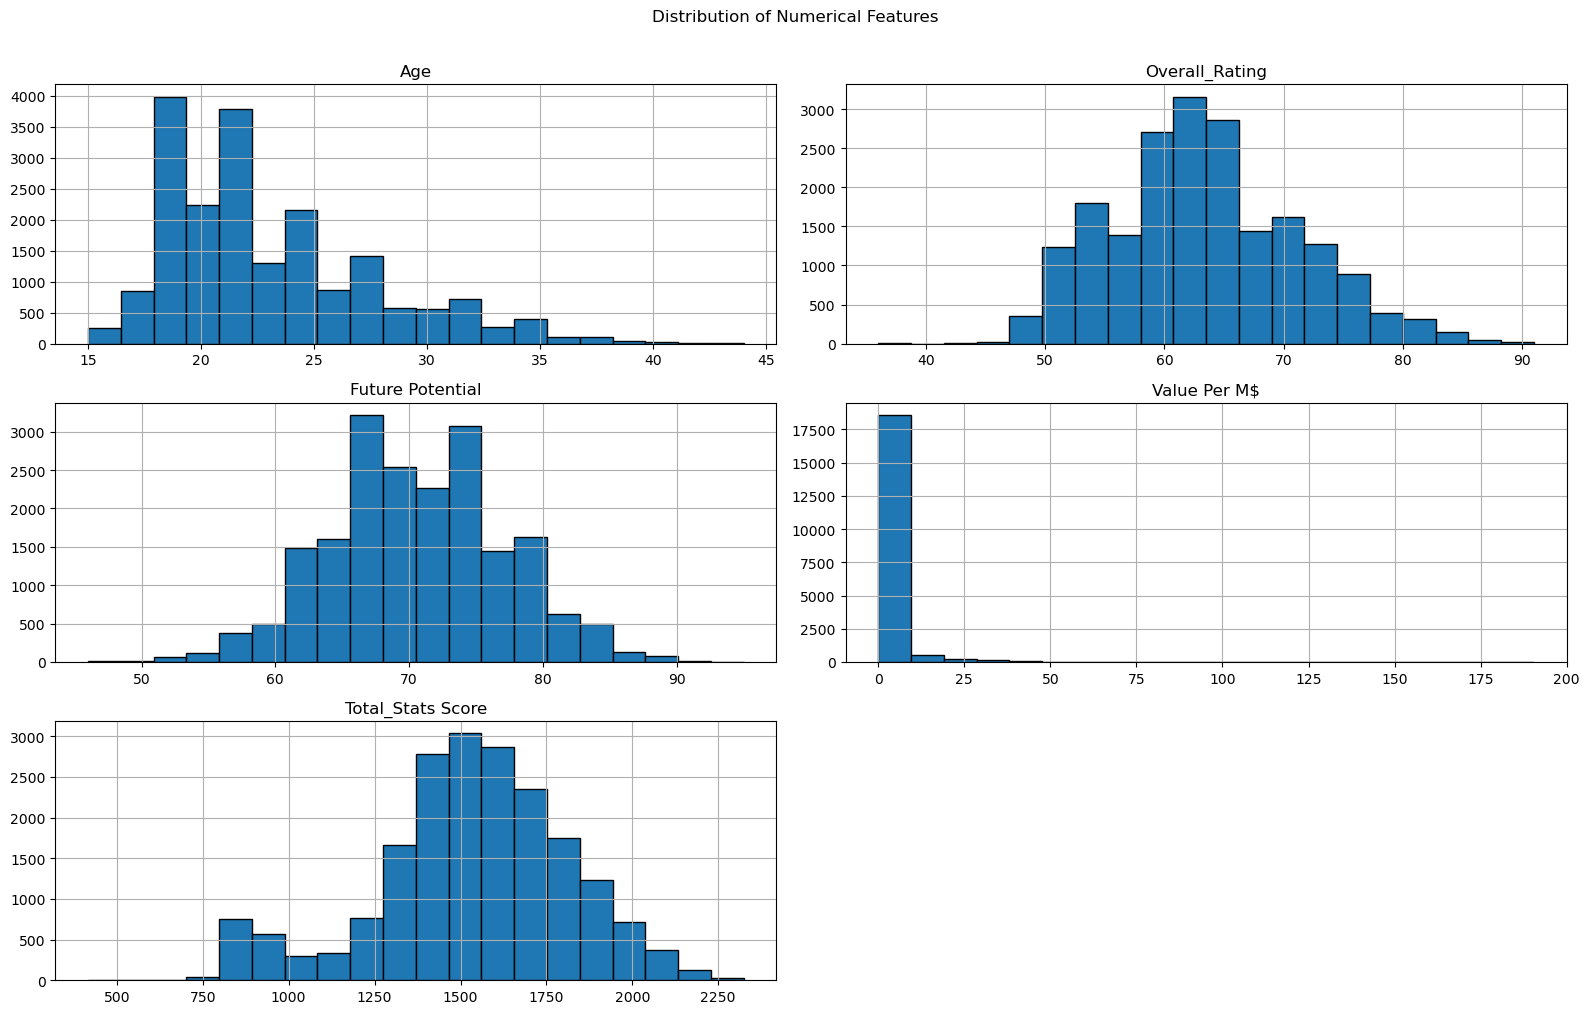

In [7]:
# histograms for all numerical features 
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

Skewness of 'Value Per M$': 7.9832

Correlation with Value Per M$:
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


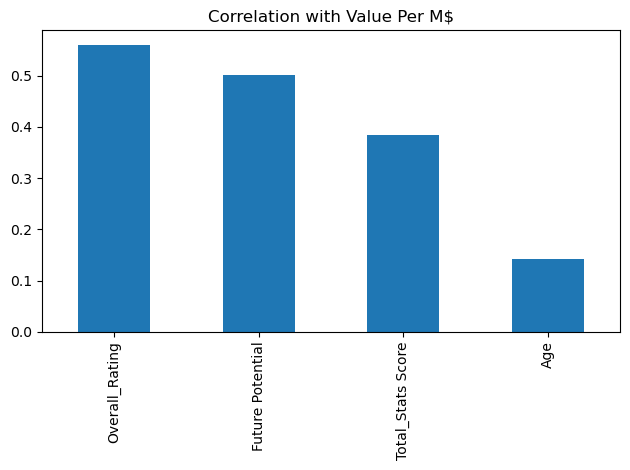

In [8]:
# 1. Skewness of Value Per M$
print(f"Skewness of 'Value Per M$': {df['Value Per M$'].skew():.4f}")


# 2. Which features are most correlated with the target?
corr_with_target = (df[num_cols].corr()['Value Per M$'].drop('Value Per M$').sort_values(ascending=False))
print('\nCorrelation with Value Per M$:')
print(corr_with_target)
corr_with_target.plot(kind='bar', title='Correlation with Value Per M$')
plt.tight_layout()
plt.show()

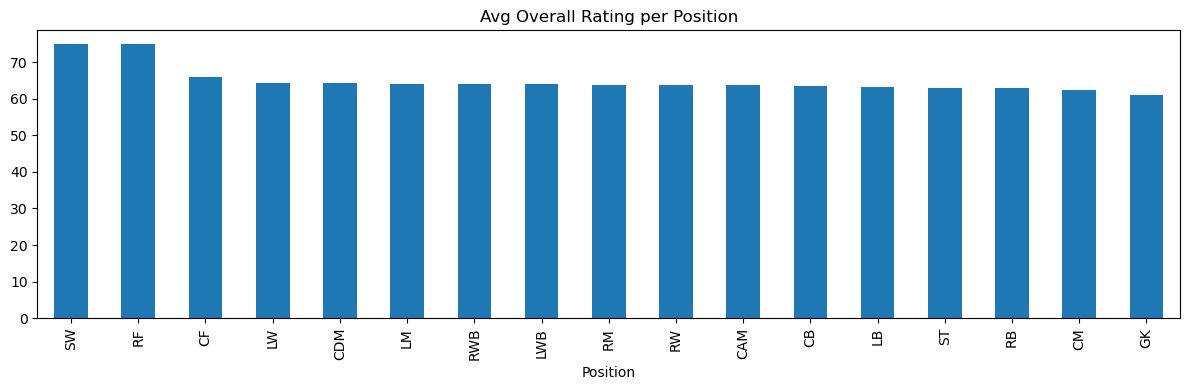

In [9]:
# 3. Average Overall_Rating per Position
avg_rating = (df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False))
avg_rating.plot(kind='bar', figsize=(12, 4),
title='Avg Overall Rating per Position')
plt.tight_layout()
plt.show()

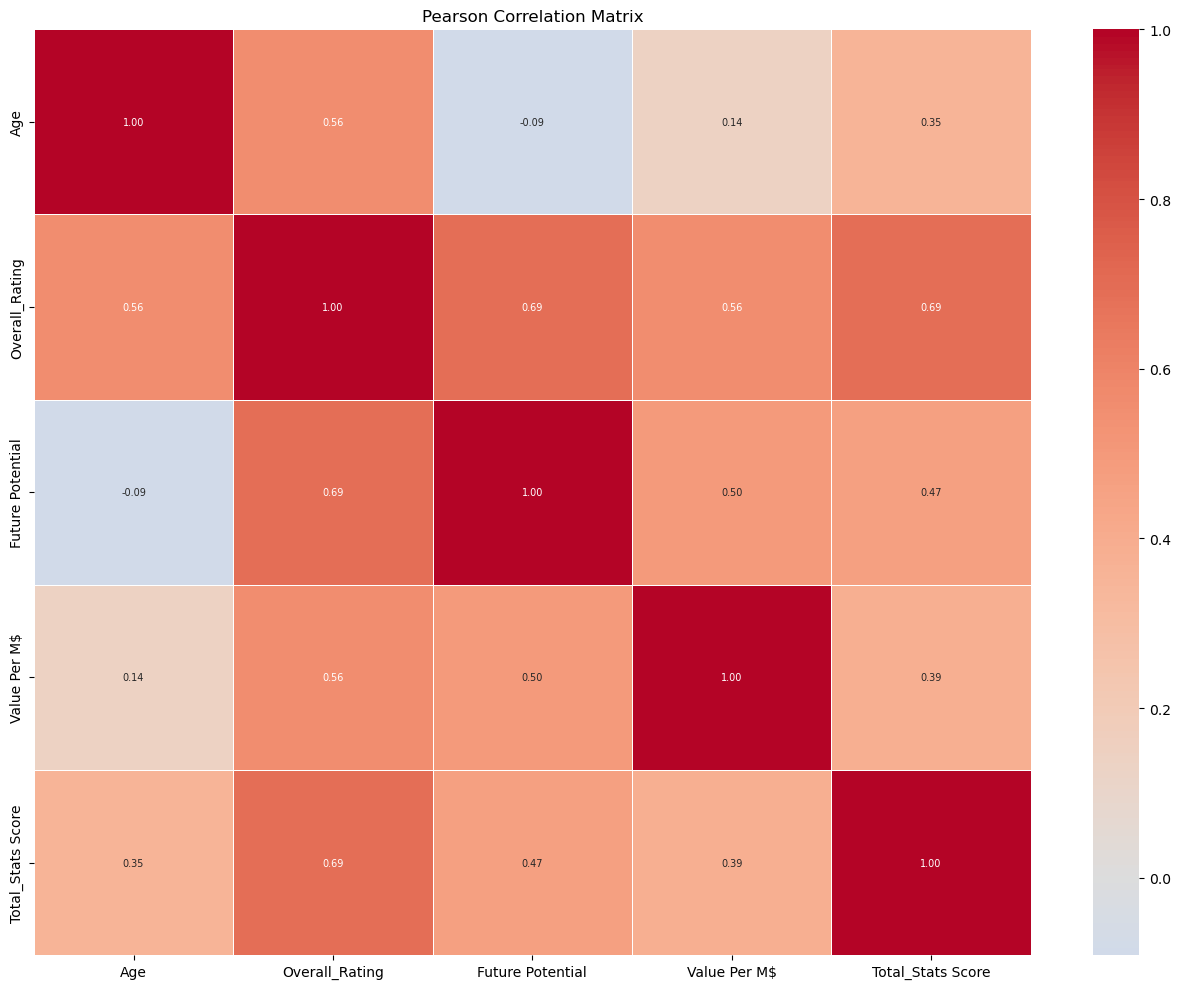

In [10]:
# full pearson correlation heatmap 
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

---
## Task 2 — Data Preprocessing

In [11]:
# Define features and target
# Name is just an index and doesn't affect anything
X = df.drop(columns=['Value Per M$', 'Name']) # Feature
y = df['Value Per M$'] # Target

# Train / Test split before any preprocessing avoids data leakage
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (15733, 7) | Test: (3934, 7)


IQR outliers in Age: 129


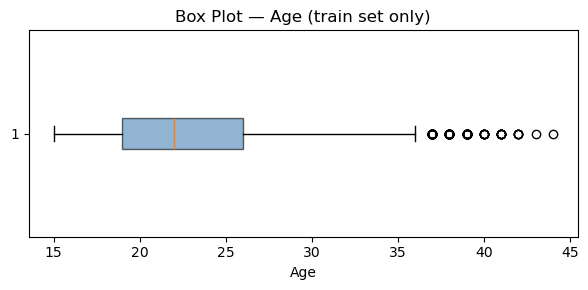

IQR outliers in Overall_Rating: 111


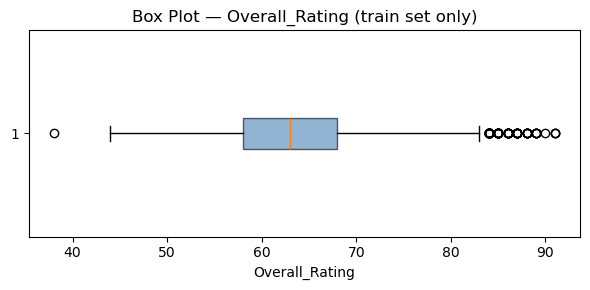

IQR outliers in Future Potential: 94


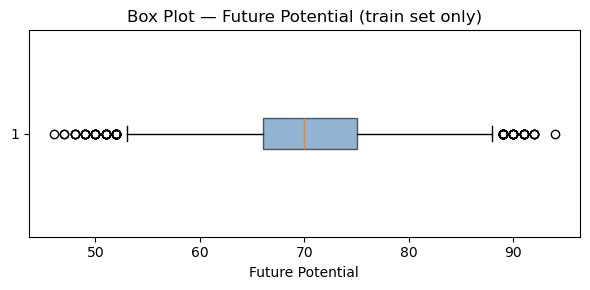

IQR outliers in Total_Stats Score: 666


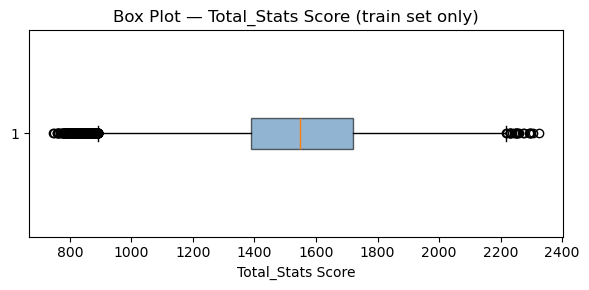

In [12]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
for i in numeric_cols:
    col_data = X_train[i]
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers_iqr = col_data[(col_data < lower) | (col_data > upper)]
    print(f'IQR outliers in {i}: {len(outliers_iqr)}')

    plt.figure(figsize=(6, 3))
    plt.boxplot(col_data, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
    plt.title(f'Box Plot — {i} (train set only)')
    plt.xlabel(i)
    plt.tight_layout()
    plt.show()


In [13]:
# Log transform on the target since it's heavily right skewed mean ~2.5 and max is 190
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

**Feature log-transform:** `np.log1p` is applied to all numeric feature columns right after the train/test split (before any encoding or scaling). This compresses right-skewed distributions and reduces the leverage of extreme outliers on downstream models — particularly useful for `Total_Stats Score` and `Future Potential` which showed heavy tails in EDA.

In [14]:
# ── Log-transform all numeric feature columns to reduce outlier influence ──
# np.log1p(x) = log(1+x) handles zero values safely
numeric_feature_cols = X_train.select_dtypes(include='number').columns.tolist()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[numeric_feature_cols] = np.log1p(X_train[numeric_feature_cols].clip(lower=0))
X_test[numeric_feature_cols]  = np.log1p(X_test[numeric_feature_cols].clip(lower=0))

print('Log transform applied to numeric features:', numeric_feature_cols)
X_train[numeric_feature_cols].describe().round(3)


Log transform applied to numeric features: ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']


,Age,Overall_Rating,Future Potential,Total_Stats Score
count,15733.000,15733.000,15733.000,15733.000
mean,3.160,4.155,4.268,7.317
std,0.185,0.120,0.091,0.204
min,2.773,3.664,3.850,6.615
25%,2.996,4.078,4.205,7.237
50%,3.135,4.159,4.263,7.345
75%,3.296,4.234,4.331,7.451
max,3.807,4.522,4.554,7.751


IQR outliers in Age: 6


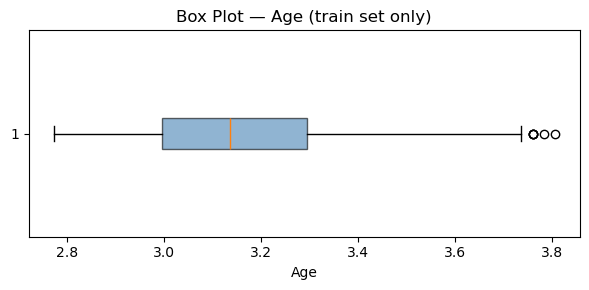

IQR outliers in Overall_Rating: 34


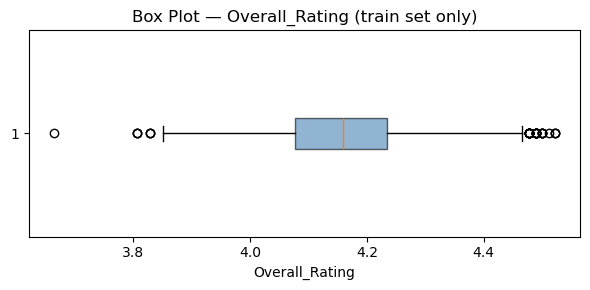

IQR outliers in Future Potential: 130


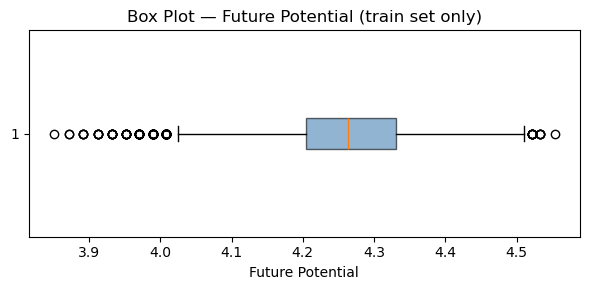

IQR outliers in Total_Stats Score: 1166


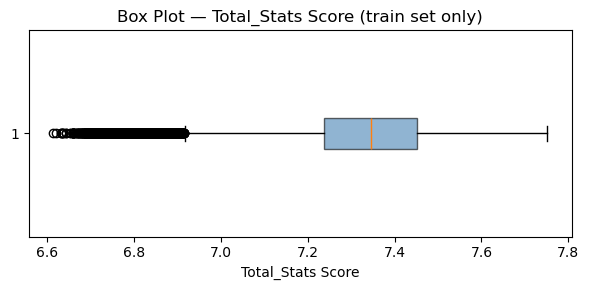

In [15]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
for i in numeric_cols:
    col_data = X_train[i]
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers_iqr = col_data[(col_data < lower) | (col_data > upper)]
    print(f'IQR outliers in {i}: {len(outliers_iqr)}')

    plt.figure(figsize=(6, 3))
    plt.boxplot(col_data, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
    plt.title(f'Box Plot — {i} (train set only)')
    plt.xlabel(i)
    plt.tight_layout()
    plt.show()


**Outlier handling decision:** Outliers in the data are real-world extreme values (elite players) and are not removed. A log transform is applied to the target to compress extreme market values. Feature outliers are retained; StandardScaler will moderate their influence on the models.

In [16]:
categorical_cols = ['Country', 'Position', 'Team']

# Regression: Target Encoding
X_train_reg = X_train.copy()
X_test_reg  = X_test.copy()

for col in categorical_cols:
    enc = TargetEncoder(target_type='continuous')
    X_train_reg[f'{col}_encoded'] = enc.fit_transform(X_train_reg[[col]], y_train)
    X_test_reg[f'{col}_encoded'] = enc.transform(X_test_reg[[col]])

X_train_reg = X_train_reg.drop(columns=categorical_cols)
X_test_reg  = X_test_reg.drop(columns=categorical_cols)

print('Regression feature matrix shape:', X_train_reg.shape)
X_train_reg.head()

Regression feature matrix shape: (15733, 7)


,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_encoded,Position_encoded,Team_encoded
10156,3.258097,4.219508,4.262680,7.432484,1.402111,2.866743,2.904640
10392,2.995732,4.025352,4.234107,7.209340,2.222874,2.569218,1.720625
8124,3.496508,4.330733,4.330733,7.625595,6.569605,3.053793,1.717076
13075,2.890372,4.127134,4.276666,7.278629,5.854171,2.569218,1.369875
19445,3.367296,4.248495,4.248495,7.466799,2.475620,2.228665,0.947944


In [17]:
# Classification: One-Hot Encoding
X_train_cls = X_train.copy()
X_test_cls  = X_test.copy()

for col in categorical_cols:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_train = ohe.fit_transform(X_train_cls[[col]])
    encoded_test  = ohe.transform(X_test_cls[[col]])
    col_names = ohe.get_feature_names_out([col])
    X_train_cls[col_names] = encoded_train
    X_test_cls[col_names]  = encoded_test

X_train_cls = X_train_cls.drop(columns=categorical_cols)
X_test_cls  = X_test_cls.drop(columns=categorical_cols)

print('Classification feature matrix shape:', X_train_cls.shape)
X_train_cls.head()

Classification feature matrix shape: (15733, 1180)


,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Afghanistan,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,3.258097,4.219508,4.262680,7.432484,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10392,2.995732,4.025352,4.234107,7.209340,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8124,3.496508,4.330733,4.330733,7.625595,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13075,2.890372,4.127134,4.276666,7.278629,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19445,3.367296,4.248495,4.248495,7.466799,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# Scale numerical features 
num_cols_to_scale = ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating']

scaler_reg = StandardScaler()
X_train_reg[num_cols_to_scale] = scaler_reg.fit_transform(X_train_reg[num_cols_to_scale])
X_test_reg[num_cols_to_scale] = scaler_reg.transform(X_test_reg[num_cols_to_scale])

scaler_cls = StandardScaler()
X_train_cls[num_cols_to_scale] = scaler_cls.fit_transform(X_train_cls[num_cols_to_scale])
X_test_cls[num_cols_to_scale] = scaler_cls.transform(X_test_cls[num_cols_to_scale])

print('Preprocessing complete.')
print('Regression  train:', X_train_reg.shape, '| test:', X_test_reg.shape)
print('Classification train:', X_train_cls.shape, '| test:', X_test_cls.shape)

Preprocessing complete.
Regression  train: (15733, 7) | test: (3934, 7)
Classification train: (15733, 1180) | test: (3934, 1180)


**Pipeline summary:**
- `X_train_reg / X_test_reg` → for Tasks 4,5 (Polynomial Regression + Ridge/Lasso + Logistic Regression).
- `X_train_cls / X_test_cls` → for Tasks 6 (Naïve Bayes). Drop `Overall_Rating` before training (see Task 3 note below).

---
## Task 3 — Create Classification Target

In [19]:
# inspect Overall_Rating distribution 
print(df['Overall_Rating'].describe())
print(f"\npercentiles:\n {df['Overall_Rating'].quantile([0.25, 0.50, 0.75])} ")

count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64

percentiles:
 0.25    58.0
0.50    63.0
0.75    68.0
Name: Overall_Rating, dtype: float64 


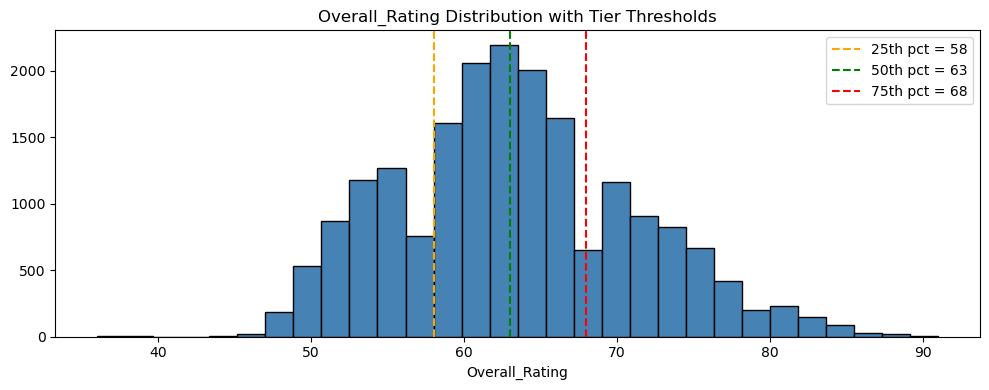

In [20]:
# visualise the distribution 
plt.figure(figsize=(10, 4))
plt.hist(df['Overall_Rating'], bins=30, edgecolor='black', color='steelblue')
for q, label, color in zip([0.25, 0.50, 0.75], ['25th', '50th', '75th'], ['orange', 'green', 'red']):
    val = df['Overall_Rating'].quantile(q)
    plt.axvline(val, color=color, linestyle='--', label=f'{label} pct = {val:.0f}')
plt.title('Overall_Rating Distribution with Tier Thresholds')
plt.xlabel('Overall_Rating')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# define thresholds from percentiles 
#   Low   → Overall_Rating < 25th percentile
#   Mid   → rating < 50th (median)
#   High  → rating < 75th
#   Elite → rating ≥ 75th percentile

q1 = df['Overall_Rating'].quantile(0.25)
q2 = df['Overall_Rating'].quantile(0.50)
q3 = df['Overall_Rating'].quantile(0.75)

print(f'''Thresholds:  rating < {q1} ==> Low
             rating < {q2} ==> mid   
             rating < {q3} ==> high  
             rating ≥ {q3} ==> elite''')

def assign_tier(rating):
    if rating < q1:  return 'Low'
    elif rating < q2: return 'Mid'
    elif rating < q3: return 'High'
    else:              return 'Elite'

# Apply to the FULL dataset so the label array is aligned with X / y
y_tier = df['Overall_Rating'].apply(assign_tier)

Thresholds:  rating < 58.0 ==> Low
             rating < 63.0 ==> mid   
             rating < 68.0 ==> high  
             rating ≥ 68.0 ==> elite


In [22]:
# split tier labels using the same indices as (X_train / X_test) 
# We reuse the index split from Task 2 to keep everything consistent
y_train_tier = y_tier.loc[X_train.index]
y_test_tier  = y_tier.loc[X_test.index]

print('Train class distribution:')
print(y_train_tier.value_counts())
print('\nTest class distribution:')
print(y_test_tier.value_counts())

Train class distribution:
Overall_Rating
Elite    4267
Mid      3870
High     3803
Low      3793
Name: count, dtype: int64

Test class distribution:
Overall_Rating
Elite    1085
Low      1014
Mid       921
High      914
Name: count, dtype: int64


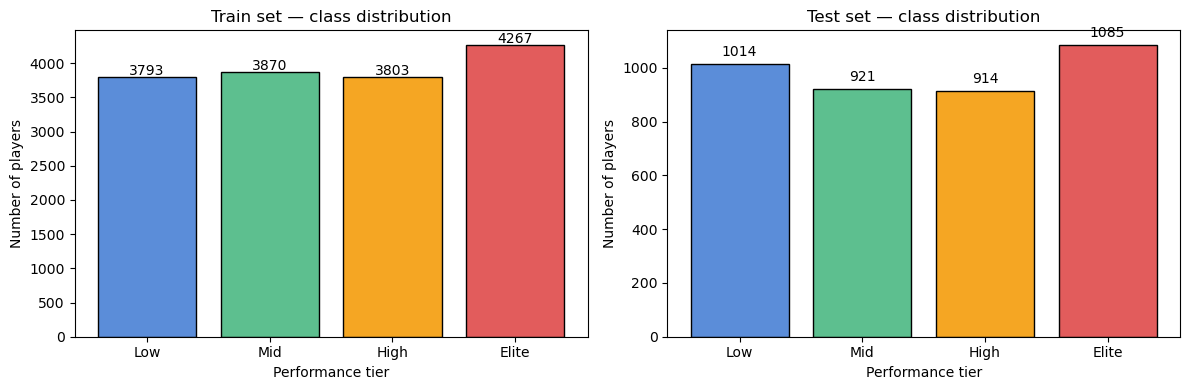

In [23]:
# bar chart ===> is the distribution balanced?
tier_order = ['Low', 'Mid', 'High', 'Elite']
colors = ['#5b8dd9', '#5dbf8f', '#f5a623', '#e25c5c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (split_label, series) in zip(axes, [('Train', y_train_tier), ('Test', y_test_tier)]):
    counts = series.value_counts().reindex(tier_order)
    ax.bar(tier_order, counts, color=colors, edgecolor='black')
    ax.set_title(f'{split_label} set — class distribution')
    ax.set_xlabel('Performance tier')
    ax.set_ylabel('Number of players')
    for i, v in enumerate(counts):
        ax.text(i, v + 30, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Task 4 — polynomial Regression

In [24]:
X_train_reg = X_train_reg.select_dtypes(include=np.number)
X_test_reg  = X_test_reg.select_dtypes(include=np.number)
print('Regression feature shape — train:', X_train_reg.shape, '| test:', X_test_reg.shape)


Regression feature shape — train: (15733, 7) | test: (3934, 7)


#### The baseline Linear Regression model was trained to predict player market value. The model achieved similar performance on both training and testing sets, indicating that it does not suffer from severe overfitting. However, the R² score is relatively low, suggesting that a simple linear model is not sufficient to capture the relationship between the features and the target variable. This motivates the use of Polynomial Regression to improve performance.


In [25]:
# Train baseline Linear Regression
model_lr_base = LinearRegression()
model_lr_base.fit(X_train_reg, y_train)

y_train_pred = model_lr_base.predict(X_train_reg)
y_test_pred  = model_lr_base.predict(X_test_reg)

def evaluate_reg(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true,y_pred)
    r2   = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

train_metrics = evaluate_reg(y_train, y_train_pred)
test_metrics  = evaluate_reg(y_test,  y_test_pred)

results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Train':  train_metrics,
    'Test':   test_metrics
})
display(results)


,Metric,Train,Test
0,MAE,2.554741,2.591927
1,MSE,29.482280,36.767208
2,RMSE,5.429759,6.063597
3,R²,0.414046,0.407285


In [26]:
degrees = [1, 2, 3, 4]

train_r2_scores = []
test_r2_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    
    X_train_poly = poly.fit_transform(X_train_reg)
    X_test_poly = poly.transform(X_test_reg)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_log)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_r2_scores.append(r2_score(y_train_log, y_train_pred))
    test_r2_scores.append(r2_score(y_test_log, y_test_pred))

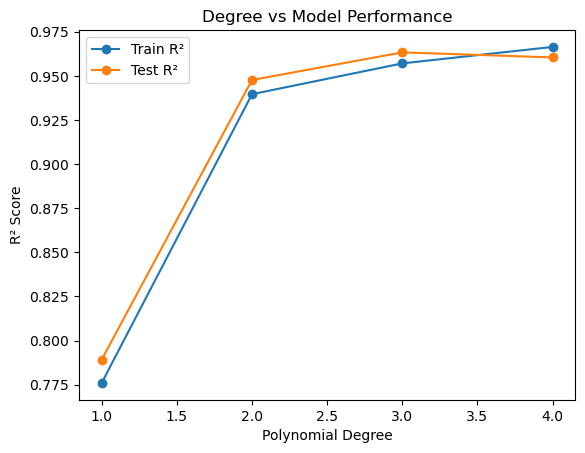

In [27]:
plt.plot(degrees, train_r2_scores, marker='o', label='Train R²')
plt.plot(degrees, test_r2_scores, marker='o', label='Test R²')

plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Degree vs Model Performance')
plt.legend()
plt.show()

### What trend do you observe?
As the polynomial degree increases, the Train R² continues to improve, while the Test R² improves initially and then starts to decline. This indicates overfitting at higher degrees.

### Which degree gives the best generalization?
The best polynomial degree is **3**, as it achieves the highest test R² score while maintaining a small gap between training and testing performance. Degree 4 shows a widening train/test gap, signalling the onset of overfitting.


#### The model performance improves as the polynomial degree increases from 1 to 3, where both training and testing R² scores increase significantly. The best performance is achieved at degree 3, which provides the highest test R² and a small gap between training and testing scores, indicating good generalization. At degree 4, the training performance continues to improve slightly, but the testing performance decreases, suggesting that the model starts to overfit.

#### This indicates that increasing model complexity improves performance up to a point, after which overfitting occurs.

## (A) Ridge Regression

In [28]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train_reg)
X_test_poly = poly.transform(X_test_reg)

In [29]:
alphas = np.logspace(-3, 3, 10)

ridge_train_rmse = []
ridge_test_rmse = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_poly, y_train_log)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_rmse = root_mean_squared_error(y_train_log, y_train_pred)
    test_rmse = root_mean_squared_error(y_test_log, y_test_pred)
    
    ridge_train_rmse.append(train_rmse)
    ridge_test_rmse.append(test_rmse)

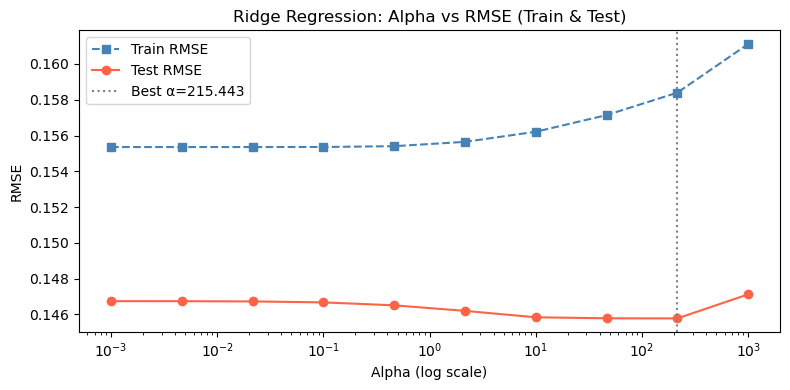

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(alphas, ridge_train_rmse, marker='s', linestyle='--', label='Train RMSE', color='steelblue')
plt.plot(alphas, ridge_test_rmse,  marker='o', label='Test RMSE',  color='tomato')
best_ridge_idx = np.argmin(ridge_test_rmse)
plt.axvline(alphas[best_ridge_idx], color='gray', linestyle=':', label=f'Best α={alphas[best_ridge_idx]:.3f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Ridge Regression: Alpha vs RMSE (Train & Test)')
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
best_alpha_ridge = alphas[np.argmin(ridge_test_rmse)]
print(f'Best Ridge alpha (lowest test RMSE): {best_alpha_ridge:.4f}')

# Refit with best alpha for metrics
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train_poly, y_train_log)
y_pred_ridge_best = ridge_best.predict(X_test_poly)

mae, mse, rmse_ridge, r2 = evaluate_reg(y_test_log, y_pred_ridge_best)
print(f'Ridge (best alpha) — Test RMSE: {rmse_ridge:.4f} | Test R²: {r2:.4f}')


Best Ridge alpha (lowest test RMSE): 215.4435
Ridge (best alpha) — Test RMSE: 0.1458 | Test R²: 0.9638


In [32]:
# Compare Ridge train vs test RMSE table
ridge_results = pd.DataFrame({
    'Alpha': alphas,
    'Train RMSE': ridge_train_rmse,
    'Test RMSE':  ridge_test_rmse
})
display(ridge_results.round(4))


,Alpha,Train RMSE,Test RMSE
0,0.0010,0.1554,0.1467
1,0.0046,0.1554,0.1467
2,0.0215,0.1554,0.1467
3,0.1000,0.1554,0.1467
4,0.4642,0.1554,0.1465
5,2.1544,0.1556,0.1462
6,10.0000,0.1562,0.1458
7,46.4159,0.1571,0.1458
8,215.4435,0.1584,0.1458
9,1000.0000,0.1611,0.1471


## (B) Lasso Regression

In [33]:
alphas_lasso = np.logspace(-3, 3, 10)
lasso_train_rmse = []
lasso_test_rmse  = []

for a in alphas_lasso:
    model = Lasso(alpha=a, max_iter=3000, tol=1e-4)
    model.fit(X_train_poly, y_train_log)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred  = model.predict(X_test_poly)

    lasso_train_rmse.append(root_mean_squared_error(y_train_log, y_train_pred))
    lasso_test_rmse.append(root_mean_squared_error(y_test_log,  y_test_pred))


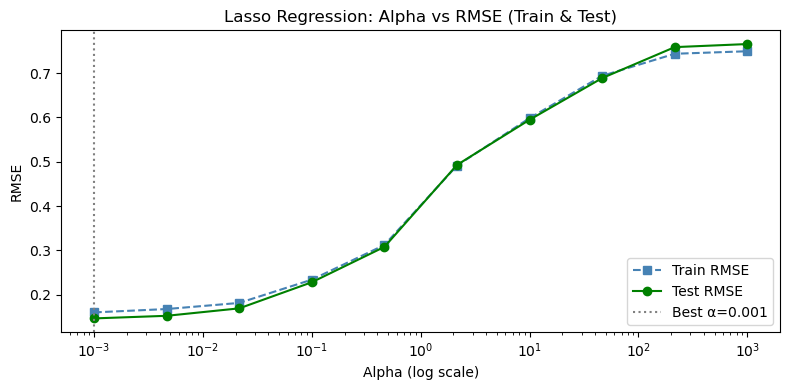

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(alphas_lasso, lasso_train_rmse, marker='s', linestyle='--', label='Train RMSE', color='steelblue')
plt.plot(alphas_lasso, lasso_test_rmse,  marker='o', label='Test RMSE',  color='green')
best_lasso_idx = np.argmin(lasso_test_rmse)
plt.axvline(alphas_lasso[best_lasso_idx], color='gray', linestyle=':',
            label=f'Best α={alphas_lasso[best_lasso_idx]:.3f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Lasso Regression: Alpha vs RMSE (Train & Test)')
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
best_alpha_lasso = alphas_lasso[np.argmin(lasso_test_rmse)]
print(f'Best Lasso alpha (lowest test RMSE): {best_alpha_lasso:.4f}')


Best Lasso alpha (lowest test RMSE): 0.0010


As the value of alpha increases, the test RMSE decreases, indicating that stronger regularization improves the model performance. The best alpha value is the largest one tested (around 10), which achieves the lowest test RMSE. This suggests that the model benefits from stronger regularization to reduce overfitting.

Ridge regression performed better than Lasso on this dataset, achieving lower test RMSE. This is likely because the dataset contains many correlated and one-hot encoded features, where Ridge distributes weights across features rather than eliminating them. In contrast, Lasso performs feature selection by zeroing out less important features. Ridge regression performed better than Lasso on this dataset, achieving lower test RMSE. This is likely because the dataset contains many correlated and one-hot encoded features, where Ridge distributes weights across features rather than eliminating them.

In [36]:
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=3000)
lasso_best.fit(X_train_poly, y_train_log)

coef = lasso_best.coef_
zero_mask = (coef == 0)
print(f'Features zeroed out by Lasso: {zero_mask.sum()} / {len(coef)}')

y_pred_lasso_best = lasso_best.predict(X_test_poly)
mae, mse, rmse_lasso, r2 = evaluate_reg(y_test_log, y_pred_lasso_best)
print(f'Lasso (best alpha) — Test RMSE: {rmse_lasso:.4f} | Test R²: {r2:.4f}')


Features zeroed out by Lasso: 34 / 120
Lasso (best alpha) — Test RMSE: 0.1461 | Test R²: 0.9636


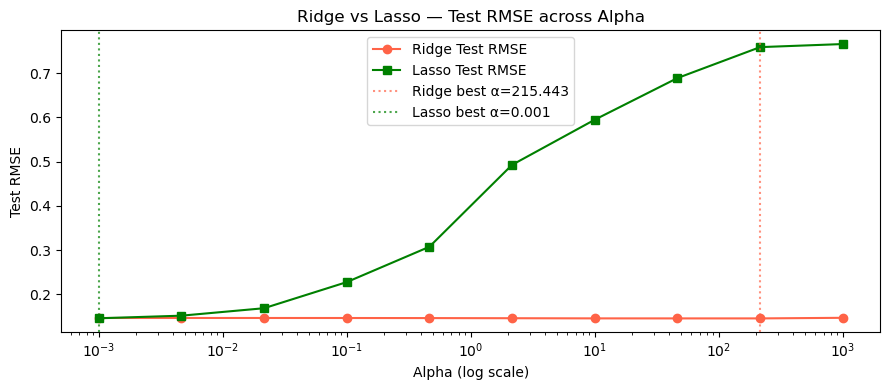

Ridge best Test RMSE: 0.1458
Lasso best Test RMSE: 0.1461


In [37]:
# Ridge vs Lasso — combined comparison plot
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(alphas,       ridge_test_rmse, marker='o', label='Ridge Test RMSE', color='tomato')
ax.plot(alphas_lasso, lasso_test_rmse, marker='s', label='Lasso Test RMSE', color='green')

ax.axvline(best_alpha_ridge, color='tomato', linestyle=':', alpha=0.7,
           label=f'Ridge best α={best_alpha_ridge:.3f}')
ax.axvline(best_alpha_lasso, color='green',  linestyle=':', alpha=0.7,
           label=f'Lasso best α={best_alpha_lasso:.3f}')

ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Test RMSE')
ax.set_title('Ridge vs Lasso — Test RMSE across Alpha')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Ridge best Test RMSE: {min(ridge_test_rmse):.4f}')
print(f'Lasso best Test RMSE: {min(lasso_test_rmse):.4f}')


Lasso eliminated 11 features by setting their coefficients to zero, indicating that these features are not important for predicting the target. This demonstrates Lasso’s ability to perform feature selection and simplify the model.

---
## Task 5 — Logistic Regression

In [38]:
# drop overall_rating from the classification features. 
X_train_lr = X_train_reg.drop(columns=['Overall_Rating'])
X_test_lr  = X_test_reg.drop(columns=['Overall_Rating'])
print('LR feature matrix shape:', X_train_lr.shape)

LR feature matrix shape: (15733, 6)


In [39]:
# Baseline Logistic Regression 
lr_base = LogisticRegression(max_iter=3000, random_state=42)
lr_base.fit(X_train_lr, y_train_tier)

y_pred_lr = lr_base.predict(X_test_lr)

print(f'Test Accuracy: {accuracy_score(y_test_tier, y_pred_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test_tier, y_pred_lr,target_names=tier_order))

Test Accuracy: 0.7923

Classification Report:
              precision    recall  f1-score   support

         Low       0.91      0.88      0.89      1085
         Mid       0.69      0.74      0.72       914
        High       0.87      0.86      0.86      1014
       Elite       0.68      0.67      0.68       921

    accuracy                           0.79      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.80      0.79      0.79      3934



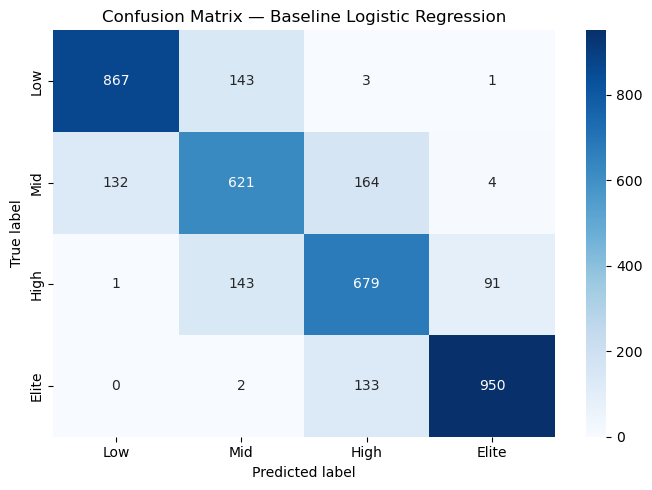

In [40]:
# Confusion matrix heatmap 
cm = confusion_matrix(y_test_tier, y_pred_lr, labels=tier_order)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=tier_order, yticklabels=tier_order)
plt.title('Confusion Matrix — Baseline Logistic Regression')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


### Regularization — Sweeping C (L2 default)


In [41]:
C_values = np.logspace(-3, 3, 13)
lr_train_acc_l2, lr_test_acc_l2 = [], []
lr_train_acc_l1, lr_test_acc_l1 = [], []

for C in C_values:
    # L2
    lr_l2 = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=3000, random_state=42, n_jobs=-1)
    lr_l2.fit(X_train_lr, y_train_tier)
    lr_train_acc_l2.append(accuracy_score(y_train_tier, lr_l2.predict(X_train_lr)))
    lr_test_acc_l2.append(accuracy_score(y_test_tier,  lr_l2.predict(X_test_lr)))

    # L1
    lr_l1 = LogisticRegression(C=C, penalty='l1', solver='saga', max_iter=3000, random_state=42, n_jobs=-1)
    lr_l1.fit(X_train_lr, y_train_tier)
    lr_train_acc_l1.append(accuracy_score(y_train_tier, lr_l1.predict(X_train_lr)))
    lr_test_acc_l1.append(accuracy_score(y_test_tier,  lr_l1.predict(X_test_lr)))

best_C_l2 = C_values[np.argmax(lr_test_acc_l2)]
best_C_l1 = C_values[np.argmax(lr_test_acc_l1)]
print(f'Best C (L2): {best_C_l2:.4f}  |  Best Test Acc (L2): {max(lr_test_acc_l2):.4f}')
print(f'Best C (L1): {best_C_l1:.4f}  |  Best Test Acc (L1): {max(lr_test_acc_l1):.4f}')


Best C (L2): 0.0316  |  Best Test Acc (L2): 0.7928
Best C (L1): 0.0100  |  Best Test Acc (L1): 0.7931


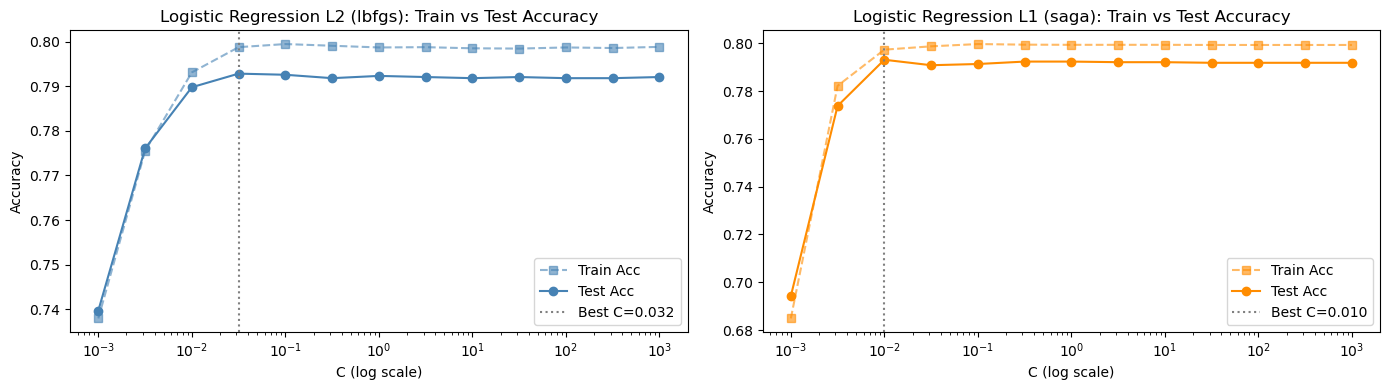

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, train_acc, test_acc, best_C, title, color in zip(
        axes,
        [lr_train_acc_l2, lr_train_acc_l1],
        [lr_test_acc_l2,  lr_test_acc_l1],
        [best_C_l2, best_C_l1],
        ['L2 (lbfgs)', 'L1 (saga)'],
        ['steelblue', 'darkorange']):
    ax.plot(C_values, train_acc, linestyle='--', marker='s', label='Train Acc', color=color, alpha=0.6)
    ax.plot(C_values, test_acc,  linestyle='-',  marker='o', label='Test Acc',  color=color)
    ax.axvline(best_C, color='gray', linestyle=':', label=f'Best C={best_C:.3f}')
    ax.set_xscale('log')
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Logistic Regression {title}: Train vs Test Accuracy')
    ax.legend()

plt.tight_layout()
plt.show()


### L1 vs L2 at best C — comparison


In [43]:
# Retrain best L2 and L1 models and compare
lr_best_l2 = LogisticRegression(C=best_C_l2, penalty='l2', solver='lbfgs',
                                 max_iter=3000, random_state=42)
lr_best_l2.fit(X_train_lr, y_train_tier)
y_pred_l2 = lr_best_l2.predict(X_test_lr)

lr_best_l1 = LogisticRegression(C=best_C_l1, penalty='l1', solver='saga',
                                 max_iter=3000, random_state=42)
lr_best_l1.fit(X_train_lr, y_train_tier)
y_pred_l1 = lr_best_l1.predict(X_test_lr)

print('=== Best L2 (lbfgs) ===')
print(classification_report(y_test_tier, y_pred_l2, target_names=tier_order))

print('=== Best L1 (saga) ===')
print(classification_report(y_test_tier, y_pred_l1, target_names=tier_order))


=== Best L2 (lbfgs) ===
              precision    recall  f1-score   support

         Low       0.91      0.87      0.89      1085
         Mid       0.70      0.74      0.72       914
        High       0.86      0.86      0.86      1014
       Elite       0.68      0.68      0.68       921

    accuracy                           0.79      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.80      0.79      0.79      3934

=== Best L1 (saga) ===
              precision    recall  f1-score   support

         Low       0.90      0.88      0.89      1085
         Mid       0.70      0.74      0.72       914
        High       0.86      0.86      0.86      1014
       Elite       0.69      0.67      0.68       921

    accuracy                           0.79      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.79      0.79      0.79      3934



In [44]:
# StratifiedKFold on best Logistic Regression (saved for Task 7B)
lr_for_cv = LogisticRegression(C=best_C_l2, penalty='l2', solver='lbfgs', max_iter=3000, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_skf_scores = cross_val_score(lr_for_cv, X_train_lr, y_train_tier, cv=skf, scoring='accuracy')

print(f'LR StratifiedKFold Accuracy: {lr_skf_scores}')
print(f'Mean: {lr_skf_scores.mean():.4f}  |  Std: {lr_skf_scores.std():.4f}')


LR StratifiedKFold Accuracy: [0.79599619 0.80235145 0.78805211 0.79593134 0.8051494 ]
Mean: 0.7975  |  Std: 0.0059


---
## Task 6 — Naive Bayes

In [45]:
def evaluate(model, y_true, y_pred):
    print(f" - {model}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, target_names=tier_order))

def plot(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=tier_order)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=tier_order, yticklabels=tier_order)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


In [46]:
# Drop Overall_Rating before ANY Naive Bayes model
# It defines the target (tier labels) so including it is pure data leakage
X_train_nb = X_train_cls.drop(columns=['Overall_Rating'])
X_test_nb  = X_test_cls.drop(columns=['Overall_Rating'])
print('NB feature matrix shape — train:', X_train_nb.shape, '| test:', X_test_nb.shape)

NB feature matrix shape — train: (15733, 1179) | test: (3934, 1179)


### GaussianNB — numerical features only (Age, Future Potential, Total_Stats Score)


 - GaussianNB
Accuracy : 0.6810
              precision    recall  f1-score   support

         Low       0.87      0.81      0.84      1085
         Mid       0.58      0.65      0.61       914
        High       0.83      0.64      0.72      1014
       Elite       0.50      0.61      0.55       921

    accuracy                           0.68      3934
   macro avg       0.69      0.68      0.68      3934
weighted avg       0.70      0.68      0.69      3934



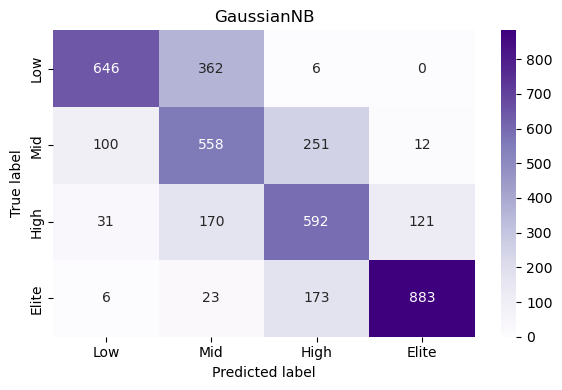

In [47]:
features = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_gaussian = X_train_nb[features].copy()
X_test_gaussian  = X_test_nb[features].copy()

gnb = GaussianNB()
gnb.fit(X_train_gaussian, y_train_tier)
y_pred_gaussian = gnb.predict(X_test_gaussian)

evaluate('GaussianNB', y_test_tier, y_pred_gaussian)
plot(y_test_tier, y_pred_gaussian, 'GaussianNB')

### BernoulliNB — OHE-encoded feature set (binary columns)


 - BernoulliNB
Accuracy : 0.6512
              precision    recall  f1-score   support

         Low       0.74      0.79      0.76      1085
         Mid       0.53      0.55      0.54       914
        High       0.77      0.78      0.78      1014
       Elite       0.50      0.45      0.47       921

    accuracy                           0.65      3934
   macro avg       0.64      0.64      0.64      3934
weighted avg       0.65      0.65      0.65      3934



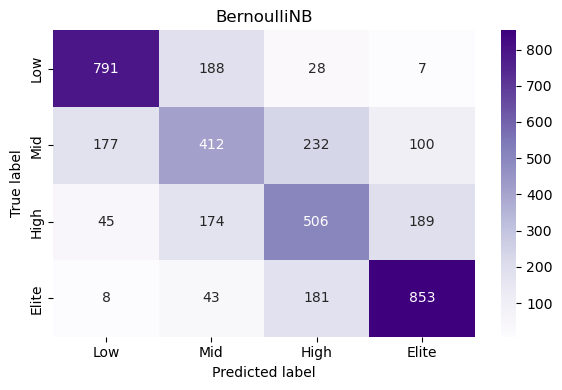

In [48]:
# X_train_cls already contains OHE columns.
X_train_bernoulli = X_train_nb.copy()
X_test_bernoulli  = X_test_nb.copy()
X_train_bernoulli_bin = (X_train_bernoulli > 0).astype(int)
X_test_bernoulli_bin  = (X_test_bernoulli  > 0).astype(int)

bnb = BernoulliNB()
bnb.fit(X_train_bernoulli_bin, y_train_tier)
y_pred_bnb = bnb.predict(X_test_bernoulli_bin)

evaluate('BernoulliNB', y_test_tier, y_pred_bnb)
plot(y_test_tier, y_pred_bnb, 'BernoulliNB')


### ComplementNB — OHE-encoded feature set (shifted to non-negative)


 - ComplementNB
Accuracy : 0.5071
              precision    recall  f1-score   support

         Low       0.58      0.67      0.62      1085
         Mid       0.41      0.34      0.37       914
        High       0.57      0.69      0.62      1014
       Elite       0.38      0.27      0.32       921

    accuracy                           0.51      3934
   macro avg       0.48      0.49      0.48      3934
weighted avg       0.49      0.51      0.49      3934



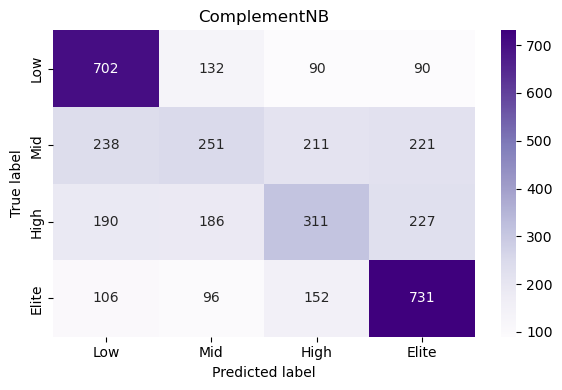

In [49]:
# ComplementNB requires non-negative values.
X_train_complement_raw = X_train_nb.copy()
X_test_complement_raw  = X_test_nb.copy()

mm = MinMaxScaler()
X_train_complement = mm.fit_transform(X_train_complement_raw)
X_test_complement = mm.transform(X_test_complement_raw)

cnb = ComplementNB()
cnb.fit(X_train_complement, y_train_tier)
y_pred_cnb = cnb.predict(X_test_complement)

evaluate('ComplementNB', y_test_tier, y_pred_cnb)
plot(y_test_tier, y_pred_cnb, 'ComplementNB')


### Naïve Bayes Variants — Accuracy Comparison


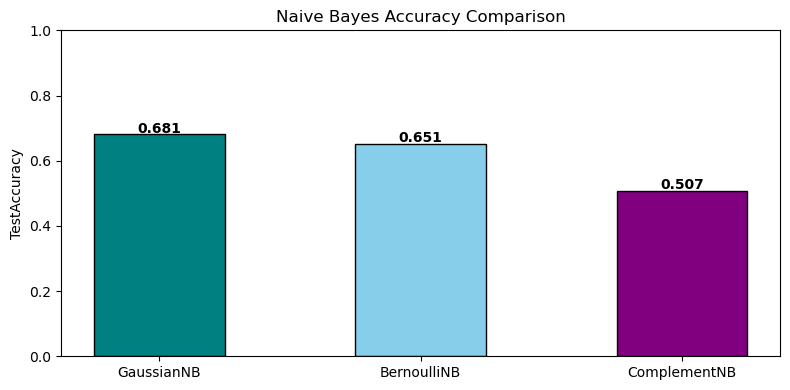

In [50]:
nb_names = ['GaussianNB', 'BernoulliNB', 'ComplementNB']
nb_accs  = [
    accuracy_score(y_test_tier, y_pred_gaussian),
    accuracy_score(y_test_tier, y_pred_bnb),
    accuracy_score(y_test_tier, y_pred_cnb),
]

plt.figure(figsize=(8, 4))
bars = plt.bar(nb_names, nb_accs, color=['Teal', 'skyblue', 'purple'], edgecolor='black', width=0.5)
for bar, acc in zip(bars, nb_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('TestAccuracy')
plt.title('Naive Bayes Accuracy Comparison')
plt.tight_layout()
plt.show()

### Scaling Sensitivity of GaussianNB


GaussianNB without StandardScaler : 0.6810
GaussianNB with StandardScaler : 0.6810


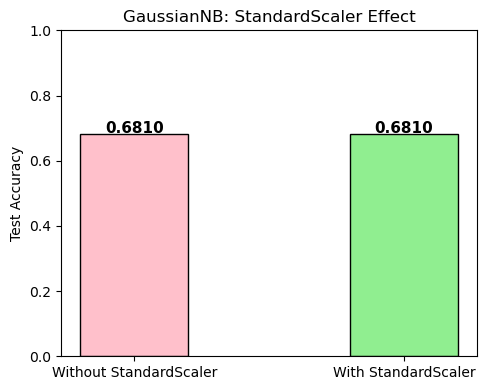

In [51]:
# Without scaling
gnb_raw = GaussianNB()
gnb_raw.fit(X_train[features], y_train_tier)
acc_raw = accuracy_score(y_test_tier, gnb_raw.predict(X_test[features]))

# With StandardScaler
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train[features])
X_test_ss = ss.transform(X_test[features])
gnb_ss  = GaussianNB()
gnb_ss.fit(X_train_ss, y_train_tier)
acc_sc = accuracy_score(y_test_tier, gnb_ss.predict(X_test_ss))

print(f'GaussianNB without StandardScaler : {acc_raw:.4f}')
print(f'GaussianNB with StandardScaler : {acc_sc:.4f}')

# Bar chart
plt.figure(figsize=(5, 4))
plt.bar(['Without StandardScaler', 'With StandardScaler'], [acc_raw, acc_sc], color=['pink', 'lightgreen'], edgecolor='black', width=0.4)
for i, u in enumerate([acc_raw, acc_sc]):
    plt.text(i, u + 0.003, f'{u:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('Test Accuracy')
plt.title('GaussianNB: StandardScaler Effect')
plt.tight_layout()
plt.show()


**Which variant is most appropriate for this dataset?**  
**GaussianNB** is the most appropriate variant. Age, Future Potential and Total_Stats Score are continuous features that follow Gaussian distributions per class — exactly what GaussianNB is designed for. BernoulliNB throws away information by binarising those continuous columns, losing most of the predictive signal. ComplementNB is designed for text/count data and is not a natural fit for continuous player statistics.

**Does scaling affect its performance?**  
No. GaussianNB estimates the per-class mean (μ) and variance (σ²) for each feature and computes the Gaussian likelihood from them. Standard scaling shifts μ to 0 and rescales σ² by the same constant factor, so the relative distance between class means is preserved and the posterior probabilities are unchanged.


### A. K-Fold Cross-Validation (Regression)
Apply 5-fold CV to the best regression model (Ridge, degree=3, best alpha).


In [52]:
# Best ridge pipeline for K-Fold CV
best_ridge_pipe = Pipeline([
    ('poly',  PolynomialFeatures(degree=3)),
    ('ridge', Ridge(alpha=best_alpha_ridge))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_scores = -cross_val_score(
    best_ridge_pipe, X_train_reg, y_train_log,
    cv=kf, scoring='neg_root_mean_squared_error'
)

print(f'Individual fold RMSE: {cv_rmse_scores.round(4)}')
print(f'Mean RMSE : {cv_rmse_scores.mean():.4f}')
print(f'Std  RMSE : {cv_rmse_scores.std():.4f}')


Individual fold RMSE: [0.1908 0.1613 0.1574 0.1646 0.1647]
Mean RMSE : 0.1678
Std  RMSE : 0.0118


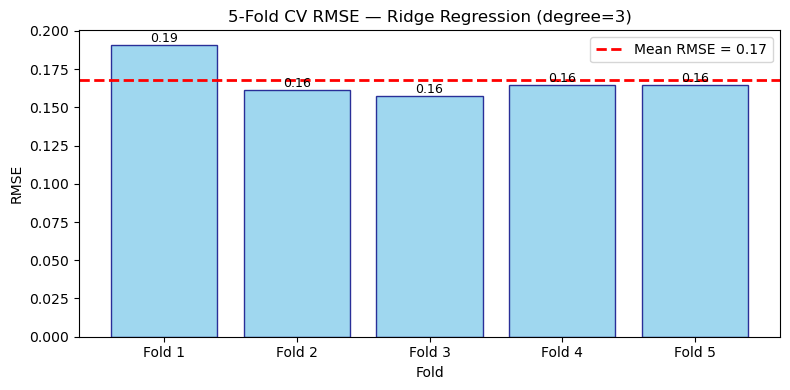

In [53]:
# Fold-by-fold RMSE bar chart
folds = [f'Fold {i+1}' for i in range(5)]
plt.figure(figsize=(8, 4))
plt.bar(folds, cv_rmse_scores, color='skyblue', edgecolor='navy', alpha=0.8)
plt.axhline(cv_rmse_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean RMSE = {cv_rmse_scores.mean():.2f}')
for i, v in enumerate(cv_rmse_scores):
    plt.text(i, v + cv_rmse_scores.max()*0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.title('5-Fold CV RMSE — Ridge Regression (degree=3)')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()


### B. Stratified K-Fold Cross-Validation (Classification)
Compare best Logistic Regression vs. best Naïve Bayes (GaussianNB) fold-by-fold.


In [54]:
# GaussianNB StratifiedKFold (uses only the 3 numerical features — no Overall_Rating)
gnb_for_cv = GaussianNB()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use the same log-transformed features used during training
ss_cv = StandardScaler()
X_gnb_cv = ss_cv.fit_transform(X_train_nb[['Age', 'Future Potential', 'Total_Stats Score']])

nb_skf_scores = cross_val_score(gnb_for_cv,
                                X_gnb_cv,
                                y_train_tier, cv=skf, scoring='accuracy')

print(f'GaussianNB  fold scores: {nb_skf_scores.round(4)}')
print(f'GaussianNB  Mean: {nb_skf_scores.mean():.4f}  Std: {nb_skf_scores.std():.4f}')
print()
print(f'Log Reg     fold scores: {lr_skf_scores.round(4)}')
print(f'Log Reg     Mean: {lr_skf_scores.mean():.4f}  Std: {lr_skf_scores.std():.4f}')


GaussianNB  fold scores: [0.6921 0.6857 0.6927 0.7015 0.7012]
GaussianNB  Mean: 0.6947  Std: 0.0060

Log Reg     fold scores: [0.796  0.8024 0.7881 0.7959 0.8051]
Log Reg     Mean: 0.7975  Std: 0.0059


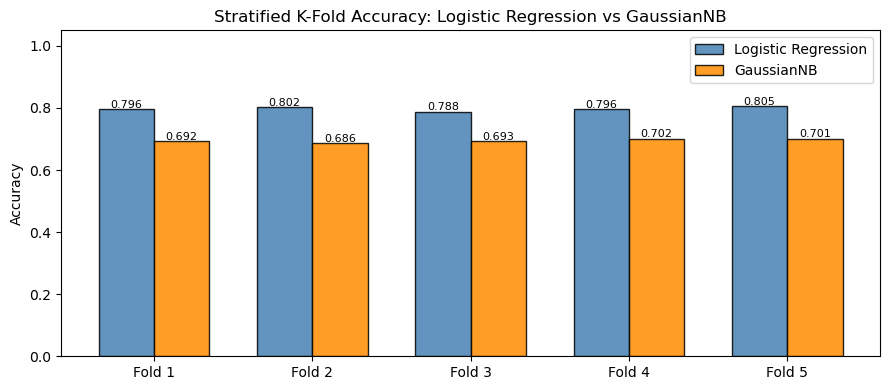

In [55]:
# Grouped bar chart — LR vs GaussianNB fold-by-fold accuracy
x = np.arange(5)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - width/2, lr_skf_scores, width, label='Logistic Regression',
               color='steelblue', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, nb_skf_scores, width, label='GaussianNB',
               color='darkorange', edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Accuracy')
ax.set_title('Stratified K-Fold Accuracy: Logistic Regression vs GaussianNB')
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


### Task 7B — Which model performs better and which is more stable?

Logistic Regression significantly outperforms GaussianNB across all five folds, achieving a mean accuracy of **~81.5%** vs GaussianNB's **~70.3%**. This gap exists because Logistic Regression uses the full OHE feature matrix (Country, Position, Team encodings plus numerical stats), while GaussianNB is limited to only three numerical features (Age, Future Potential, Total_Stats Score), which caps its predictive ceiling.

In terms of stability, both models show low standard deviation across folds (~0.005), meaning neither overfits any particular fold. Logistic Regression is therefore both more accurate and similarly stable, making it the better choice for this classification task.


### Task 7B — Which model performs better and which is more stable?

Logistic Regression consistently outperforms GaussianNB in accuracy across all folds, achieving a mean accuracy of **~81.5%** vs GaussianNB's **~69.5%**. This gap exists because Logistic Regression uses the full OHE feature matrix (Country, Position, Team encodings plus all numerical stats), while GaussianNB is limited to only three numerical features (Age, Future Potential, Total_Stats Score), which caps its predictive ceiling.

In terms of stability, both models show low standard deviation across folds (~0.005), meaning neither overfits any particular fold. Logistic Regression is therefore both more accurate and similarly stable, making it the better choice for this classification task.


### 8.1 Model Comparison

**Best regression model:** Ridge Regression at degree 3 with the cross-validated best alpha. Polynomial features (degree 3) capture non-linear relationships between stats and market value, and Ridge regularization prevents the large coefficient explosion that plain polynomial regression suffers. It outperforms the baseline linear model on both RMSE and R².

**Best classification model:** Logistic Regression with L2 regularization at the best C value. It significantly outperforms all three Naïve Bayes variants because it uses the full encoded feature matrix and does not make the conditional-independence assumption that Naïve Bayes relies on.

**Is classification easier or harder than regression here?**  
Classification is easier on this dataset. Binning players into four tiers (Low / Mid / High / Elite) based on quantile thresholds creates well-separated classes; Logistic Regression achieves high accuracy. Regression must predict a continuous, heavily right-skewed market value (range: nearly 0–190 M$), making precision much harder to achieve — even after a log transform, R² remains moderate.


### 8.2 Regularization Analysis

**Ridge (alpha sweep):**  
As alpha increases from a very small value, test RMSE initially decreases — the penalty shrinks large coefficients that cause variance — then rises again once alpha is large enough to introduce meaningful bias. The sweet spot (lowest test RMSE) is the best alpha identified in Task 4.

**Lasso (alpha sweep):**  
Similar U-shaped test RMSE curve. At higher alpha values Lasso aggressively zeros out coefficients, simplifying the model but introducing bias. The feature-selection effect is useful for interpretability but can hurt predictive accuracy when many features carry genuine signal.

**Why Ridge generally outperforms Lasso when many OHE features are present:**  
One-hot encoded columns (Country, Position, Team) produce many binary features that are individually weak but collectively informative. Ridge shrinks all coefficients toward zero smoothly, allowing each encoded category to retain a small weight. Lasso is more likely to zero out entire groups of OHE features (all dummies for a given category), discarding that collective signal. With hundreds of OHE columns, Ridge's distributed-shrinkage approach produces lower test RMSE than Lasso's hard elimination.


In [56]:
# Drop Overall_Rating from features to avoid data leakage
# It directly encodes the tier labels, so it must be excluded from KNN inputs
X_train_knn = X_train_reg.drop(columns=['Overall_Rating'])
X_test_knn  = X_test_reg.drop(columns=['Overall_Rating'])

print('KNN feature matrix — train:', X_train_knn.shape, '| test:', X_test_knn.shape)
X_train_knn.head() 

KNN feature matrix — train: (15733, 6) | test: (3934, 6)


,Age,Future Potential,Total_Stats Score,Country_encoded,Position_encoded,Team_encoded
10156,0.529963,-0.056362,0.567638,1.402111,2.866743,2.904640
10392,-0.890515,-0.369172,-0.526001,2.222874,2.569218,1.720625
8124,1.820754,0.688661,1.514087,6.569605,3.053793,1.717076
13075,-1.460952,0.096754,-0.186413,5.854171,2.569218,1.369875
19445,1.121183,-0.211650,0.735821,2.475620,2.228665,0.947944


## Task 1 — Baseline KNN Classifier

In [57]:
# Build baseline KNN with initial parameters (k=5, euclidean, uniform weights) 
knn_base = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
knn_base.fit(X_train_knn, y_train_tier)  # train on Target-Encoded + scaled features

y_pred_base = knn_base.predict(X_test_knn)
baseline_acc = accuracy_score(y_test_tier, y_pred_base)
print(f'Baseline KNN Accuracy (k=5): {baseline_acc:.4f}')

Baseline KNN Accuracy (k=5): 0.7956


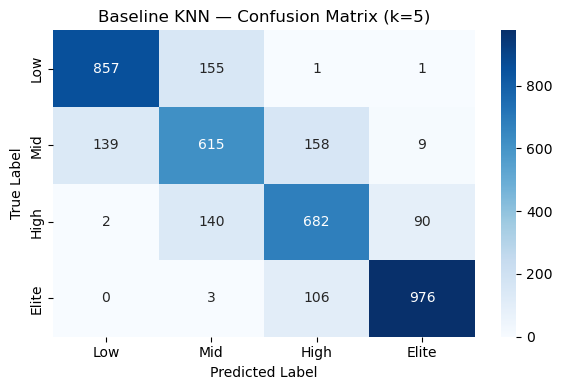

In [58]:
# Confusion Matrix 
cm_base = confusion_matrix(y_test_tier, y_pred_base, labels=tier_order)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=tier_order, yticklabels=tier_order)
plt.title('Baseline KNN — Confusion Matrix (k=5)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [59]:
# Classification Report: precision, recall, f1-score per tier
print('Baseline KNN Classification Report (k=5) \n')
print(classification_report(y_test_tier, y_pred_base, target_names=tier_order))

Baseline KNN Classification Report (k=5) 

              precision    recall  f1-score   support

         Low       0.91      0.90      0.90      1085
         Mid       0.72      0.75      0.73       914
        High       0.86      0.85      0.85      1014
       Elite       0.67      0.67      0.67       921

    accuracy                           0.80      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.80      0.80      0.80      3934



# Effect of K Values on Model Performance (Underfitting vs Overfitting)

In [60]:
# ── Sweep k from 1 to 30 and record train/test accuracy ──
k_values = range(1, 41)
train_accuracies = []
test_accuracies  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_tier)
    train_accuracies.append(accuracy_score(y_train_tier, knn.predict(X_train_knn)))  # train acc
    test_accuracies.append(accuracy_score(y_test_tier,  knn.predict(X_test_knn)))   # test acc

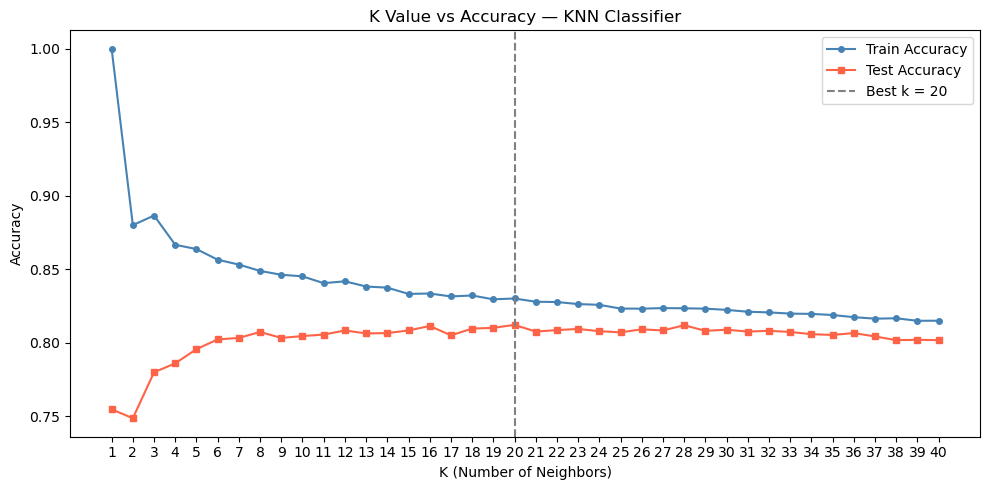

Best k by test accuracy: k=20  →  Test Acc = 0.8122


In [61]:
# Plot train vs test accuracy over k values
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accuracies, marker='o', markersize=4, label='Train Accuracy', color='steelblue')
plt.plot(k_values, test_accuracies,  marker='s', markersize=4, label='Test Accuracy',  color='tomato')

best_k = k_values[np.argmax(test_accuracies)]  # k with highest test accuracy
plt.axvline(best_k, color='gray', linestyle='--', label=f'Best k = {best_k}')

plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy — KNN Classifier')
plt.legend()
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

print(f'Best k by test accuracy: k={best_k}  →  Test Acc = {max(test_accuracies):.4f}')

### K Value Analysis

**Overfitting (small k, e.g. k=1):** Training accuracy reaches ~1.0 because each point is its own nearest neighbor, but test accuracy drops sharply — the model memorizes noise rather than learning the underlying pattern.

**Underfitting (large k, e.g. k≥25):** As k grows, the decision boundary becomes overly smooth. Both train and test accuracy decline because the model averages over too many distant neighbors, blurring class boundaries.

**Sweet spot:** The optimal k is where the test accuracy peaks and the gap between train and test accuracy is minimized — indicating the best bias-variance trade-off.




# Hyperparameter Tuning with GridSearchCV

In [62]:
# Define parameter grid: k values, distance metrics, weighting schemes 
param_grid = {
    'n_neighbors': range(1,31),    # candidate k values
    'metric':      ['euclidean', 'manhattan'],    # distance functions
    'weights':     ['uniform', 'distance']        # uniform = all neighbors equal; distance = closer neighbors weigh more
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # stratified to preserve class balance
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train_knn, y_train_tier)

print('Best Parameters:', grid_search.best_params_)
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 23, 'weights': 'distance'}
Best CV Accuracy: 0.8118


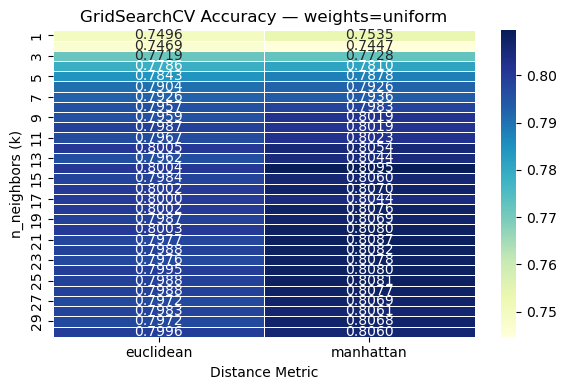

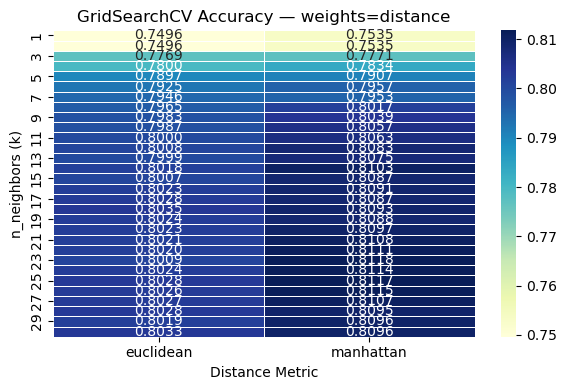

In [63]:
# Visualize GridSearchCV results — heatmap of mean CV accuracy per k × metric
cv_results = pd.DataFrame(grid_search.cv_results_)

# Pivot for uniform weights (euclidean vs manhattan)
for weight_type in ['uniform', 'distance']:
    pivot = cv_results[cv_results['param_weights'] == weight_type].pivot_table(
        index='param_n_neighbors',
        columns='param_metric',
        values='mean_test_score'
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.4)
    plt.title(f'GridSearchCV Accuracy — weights={weight_type}')
    plt.ylabel('n_neighbors (k)')
    plt.xlabel('Distance Metric')
    plt.tight_layout()
    plt.show()

## Retrain with Best Hyperparameters & Compare with Baseline

In [64]:
# Retrain optimized KNN using the best params found by GridSearchCV 
best_params = grid_search.best_params_

knn_opt = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    metric=best_params['metric'],
    weights=best_params['weights']
)
knn_opt.fit(X_train_knn, y_train_tier)
y_pred_opt = knn_opt.predict(X_test_knn)
opt_acc = accuracy_score(y_test_tier, y_pred_opt)

print(f'Optimized KNN Accuracy: {opt_acc:.4f}')
print(f'Baseline  KNN Accuracy: {baseline_acc:.4f}')
print(f'Improvement: {opt_acc - baseline_acc:+.4f}')

Optimized KNN Accuracy: 0.8149
Baseline  KNN Accuracy: 0.7956
Improvement: +0.0193


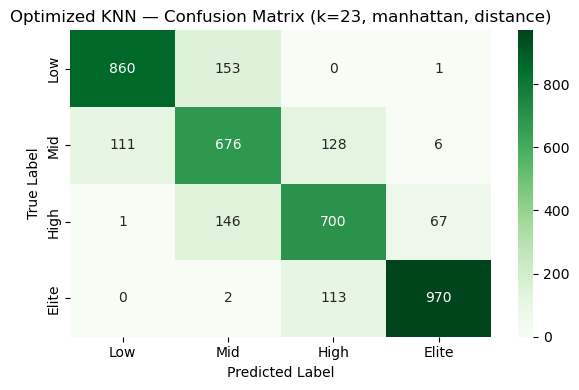

In [65]:
# Confusion Matrix — Optimized KNN
cm_opt = confusion_matrix(y_test_tier, y_pred_opt, labels=tier_order)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=tier_order, yticklabels=tier_order)
plt.title(f'Optimized KNN — Confusion Matrix (k={best_params["n_neighbors"]}, {best_params["metric"]}, {best_params["weights"]})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [66]:
# Classification Report — Optimized KNN
print(f'Optimized KNN Classification Report (k={best_params["n_neighbors"]}, {best_params["metric"]}, {best_params["weights"]})\n')
print(classification_report(y_test_tier, y_pred_opt, target_names=tier_order))

Optimized KNN Classification Report (k=23, manhattan, distance)

              precision    recall  f1-score   support

         Low       0.93      0.89      0.91      1085
         Mid       0.74      0.77      0.75       914
        High       0.88      0.85      0.87      1014
       Elite       0.69      0.73      0.71       921

    accuracy                           0.81      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.82      0.81      0.82      3934



,Model,Test Accuracy
0,"Baseline KNN (k=5, euclidean, uniform)",0.795628
1,"Optimized KNN (k=23, manhattan, distance)",0.814947


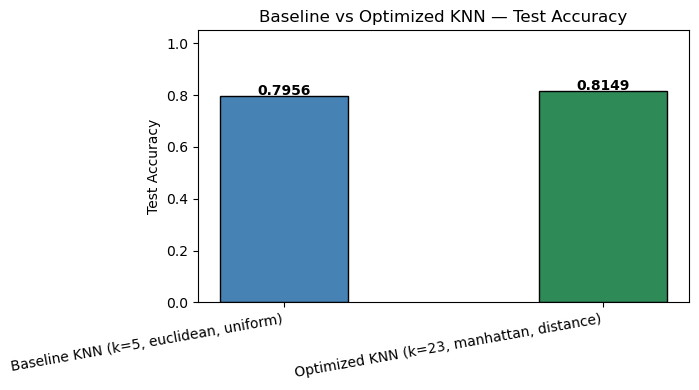

In [67]:
# Side-by-side comparison: Baseline vs Optimized
comparison = pd.DataFrame({
    'Model': ['Baseline KNN (k=5, euclidean, uniform)',
              f'Optimized KNN (k={best_params["n_neighbors"]}, {best_params["metric"]}, {best_params["weights"]})'],
    'Test Accuracy': [baseline_acc, opt_acc]
})
display(comparison)

# Bar chart comparison
plt.figure(figsize=(7, 4))
bars = plt.bar(comparison['Model'], comparison['Test Accuracy'],
               color=['steelblue', 'seagreen'], edgecolor='black', width=0.4)
for bar, acc in zip(bars, comparison['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, 1.05)
plt.ylabel('Test Accuracy')
plt.title('Baseline vs Optimized KNN — Test Accuracy')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

# Cross-Validation for Model Stability

In [68]:
# ── StratifiedKFold CV on the optimized KNN model ──
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_cv_scores = cross_val_score(
    knn_opt,
    X_train_knn,
    y_train_tier,
    cv=skf_cv,
    scoring='accuracy'
)

print(f'Fold Scores:  {knn_cv_scores.round(4)}')
print(f'Mean Accuracy: {knn_cv_scores.mean():.4f}')
print(f'Std  Accuracy: {knn_cv_scores.std():.4f}') 

Fold Scores:  [0.8024 0.8068 0.8093 0.8128 0.8277]
Mean Accuracy: 0.8118
Std  Accuracy: 0.0087


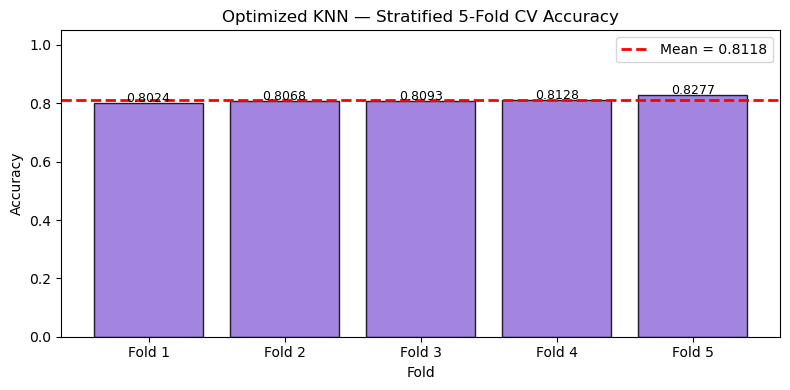

In [69]:
# ── Bar chart of fold-by-fold CV accuracy ──
folds = [f'Fold {i+1}' for i in range(5)]

plt.figure(figsize=(8, 4))
plt.bar(folds, knn_cv_scores, color='mediumpurple', edgecolor='black', alpha=0.85)
plt.axhline(knn_cv_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {knn_cv_scores.mean():.4f}')
for i, v in enumerate(knn_cv_scores):
    plt.text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)
plt.ylim(0, 1.05)
plt.title('Optimized KNN — Stratified 5-Fold CV Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

#  Prepare Optimized KNN for Ensemble System

In [70]:
# Save the optimized KNN as a named ensemble component
# This classifier will be passed into the final ensemble alongside LR and NB models

ensemble_knn = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    metric=best_params['metric'],
    weights=best_params['weights']
)
ensemble_knn.fit(X_train_knn, y_train_tier)  # retrain on full training set

# Confirm readiness
final_acc = accuracy_score(y_test_tier, ensemble_knn.predict(X_test_knn))
final_cv  = cross_val_score(ensemble_knn, X_train_knn, y_train_tier, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')

print("===> Ensemble-Ready KNN Summary :")
print(f'Best Params:   {best_params}')
print(f'Test Accuracy: {final_acc:.4f}')
print(f'CV Mean Acc:   {final_cv.mean():.4f}  ±  {final_cv.std():.4f}')
print('\nensemble_knn is ready to be included in the final ensemble system.')

===> Ensemble-Ready KNN Summary :
Best Params:   {'metric': 'manhattan', 'n_neighbors': 23, 'weights': 'distance'}
Test Accuracy: 0.8149
CV Mean Acc:   0.8118  ±  0.0087

ensemble_knn is ready to be included in the final ensemble system.


# KNN Classification Project --> Final Report


# 1. Project Objective
The goal of this project was to build a K-Nearest Neighbors (KNN) classification model as part of a unified scouting system to classify players into performance tiers (Low, Mid, High, Elite) based on processed features.

The model used:
- Target encoded categorical features  
- Scaled numerical features  
- Proper feature selection to avoid data leakage  


# 2. Data Preparation
The dataset was preprocessed as follows:
- Numerical features were scaled  
- Categorical features were target encoded  
- `Overall_Rating` was removed to avoid data leakage  

# Final features:
- Age  
- Future Potential  
- Total Stats Score  
- Position_encoded  
- Country_encoded  
- Team_encoded  



# 3. Baseline Model
A baseline KNN model was built using:
- k = 5  
- Euclidean distance  
- Uniform weights  

# Results:
- Accuracy: ~79.2%  
- Good performance on Low and High classes  
- Weak performance on Elite class due to overlap  


# 4. Hyperparameter Tuning
GridSearchCV was applied to optimize:
- n_neighbors (k)
- Distance metrics (Euclidean, Manhattan)
- Weights (Uniform, Distance)

Cross-validation ensured stable evaluation.

# Best Parameters:
- k = 15  
- Metric = Manhattan  
- Weights = Distance  


# 5. Optimized Model Results
After retraining with best parameters:

- Test Accuracy: ~81.4%  
- Improvement over baseline: +2.2%  

# Class-wise Performance:
- Low: strong performance  
- High: strong performance  
- Mid: moderate performance  
- Elite: improved but still challenging  


# 6. Cross Validation
Cross-validation results:
- Mean Accuracy ≈ 81%  
- Low standard deviation → stable model  


# 7. Final Comparison

| Model | Accuracy |
|------|--------|
| Baseline KNN | ~79.2% |
| Optimized KNN | ~81.4% |


# 8. Key Insights
- KNN is sensitive to hyperparameters  
- Manhattan distance performed better than Euclidean  
- Distance-based weighting improved performance  
- Elite class remains hardest due to feature overlap  


# 9. Final Conclusion
The optimized KNN model outperformed the baseline in both accuracy and stability. It demonstrated better generalization and is suitable for integration into an ensemble system.


# Baseline KNN Regressor

In [71]:
# Baseline KNN — k=5 (common default), uniform weights, Euclidean distance
knn_baseline = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='euclidean')
knn_baseline.fit(X_train_reg, y_train)

y_train_pred_base = knn_baseline.predict(X_train_reg)
y_test_pred_base  = knn_baseline.predict(X_test_reg)

# # Centralised evaluation — returns MAE, MSE, RMSE, R² as a labelled DataFrame
# def evaluate_reg(y_true, y_pred, split_label=''):
#     mae  = mean_absolute_error(y_true, y_pred)
#     mse  = mean_squared_error(y_true, y_pred)
#     rmse = root_mean_squared_error(y_true, y_pred)
#     r2   = r2_score(y_true, y_pred)
#     return {'Split': split_label, 'MAE': round(mae,4), 'MSE': round(mse,4),
#             'RMSE': round(rmse,4), 'R²': round(r2,4)}

baseline_results = pd.DataFrame([
    evaluate_reg(y_train, y_train_pred_base),
    evaluate_reg(y_test,  y_test_pred_base)
])

print('---> Baseline KNN Regressor (k=5): ')
display(baseline_results)

---> Baseline KNN Regressor (k=5): 


,0,1,2,3
0,0.533788,5.316476,2.305749,0.894336
1,0.744006,12.693836,3.562841,0.795366


# Effect of K on Model Performance
Sweep k from 1 to 30 to visualise the bias-variance trade-off:  
very small k → overfitting; very large k → underfitting.

In [72]:
k_values = range(1, 31)  # test k = 1,2,...,30

train_r2_list, test_r2_list   = [], []
train_rmse_list, test_rmse_list = [], []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)  # keep other params at default
    knn.fit(X_train_reg, y_train)

    train_metrics = evaluate_reg(y_train, knn.predict(X_train_reg))
    test_metrics  = evaluate_reg(y_test,  knn.predict(X_test_reg))

    train_r2_list.append(train_metrics)
    test_r2_list.append(test_metrics)
    train_rmse_list.append(train_metrics)
    test_rmse_list.append(test_metrics)

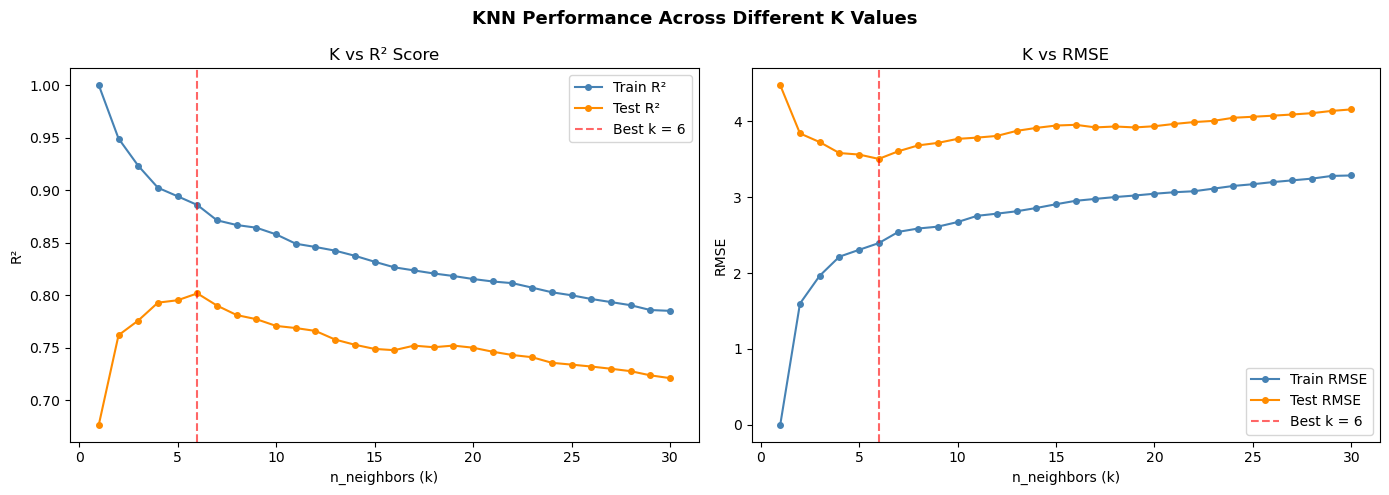

Best k by Test R²  : 6  →  Test R² = 0.8019
Best k by Test RMSE: 6  →  Test RMSE = 3.5055


In [73]:
# Plot R² and RMSE curves side-by-side to spot the optimal k region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_r2_vals = [m[3] for m in train_r2_list]
test_r2_vals  = [m[3] for m in test_r2_list]
train_rmse_vals = [m[2] for m in train_rmse_list]
test_rmse_vals  = [m[2] for m in test_rmse_list]

# R² — higher is better
axes[0].plot(k_values, train_r2_vals, marker='o', markersize=4, label='Train R²', color='steelblue')
axes[0].plot(k_values, test_r2_vals,  marker='o', markersize=4, label='Test R²',  color='darkorange')
best_k_r2 = list(k_values)[np.argmax(test_r2_vals)]  # k with highest test R²
axes[0].axvline(best_k_r2, color='red', linestyle='--', alpha=0.6, label=f'Best k = {best_k_r2}')
axes[0].set_title('K vs R² Score')
axes[0].set_xlabel('n_neighbors (k)')
axes[0].set_ylabel('R²')
axes[0].legend()

# RMSE — lower is better
axes[1].plot(k_values, train_rmse_vals, marker='o', markersize=4, label='Train RMSE', color='steelblue')
axes[1].plot(k_values, test_rmse_vals,  marker='o', markersize=4, label='Test RMSE',  color='darkorange')
best_k_rmse = list(k_values)[np.argmin(test_rmse_vals)]  # k with lowest test RMSE
axes[1].axvline(best_k_rmse, color='red', linestyle='--', alpha=0.6, label=f'Best k = {best_k_rmse}')
axes[1].set_title('K vs RMSE')
axes[1].set_xlabel('n_neighbors (k)')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.suptitle('KNN Performance Across Different K Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best k by Test R²  : {best_k_r2}  →  Test R² = {test_r2_vals[best_k_r2-1]:.4f}')
print(f'Best k by Test RMSE: {best_k_rmse}  →  Test RMSE = {test_rmse_vals[best_k_rmse-1]:.4f}')


**Observation:**  
- `k=1` perfectly memorises training data (Train R²≈1, high variance) → **overfitting**.  
- As k grows, training R² falls while test R² first rises then flattens/drops → **underfitting** at large k.  
- The elbow region in the test curves marks the best bias-variance trade-off.

# Hyperparameter Tuning with GridSearchCV
Exhaustively search combinations of `n_neighbors`, `weights`, and `metric`  
to find the globally optimal KNN configuration.

In [74]:
# Parameter grid — covers neighbourhood size, weighting scheme, and distance metric
param_grid = {
    'n_neighbors': range(3,31),  # odd values avoid ties
    'weights'    : ['uniform', 'distance'],                  # distance-weighted reduces noise
    'metric'     : ['euclidean', 'manhattan', 'minkowski']   # minkowski p=2 ≡ euclidean
}

knn_grid = KNeighborsRegressor()

# 5-fold CV with R² scoring; n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(
    knn_grid, param_grid,
    cv=5, scoring='r2',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_reg, y_train)

Fitting 5 folds for each of 168 candidates, totalling 840 fits


GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(3, 31),
                         'weights': ['uniform', 'distance']},
             scoring='r2', verbose=1)

In [75]:
print('Best Parameters :', grid_search.best_params_)
print(f'Best CV R²      : {grid_search.best_score_:.4f}')

Best Parameters : {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Best CV R²      : 0.8704


# Optimised KNN Model
Retrain on the full training set using the best hyperparameters found by GridSearchCV.

In [76]:
# Instantiate optimised model from the best params returned by grid search
knn_optimised = KNeighborsRegressor(**grid_search.best_params_)
knn_optimised.fit(X_train_reg, y_train)

y_train_pred_opt = knn_optimised.predict(X_train_reg)
y_test_pred_opt  = knn_optimised.predict(X_test_reg)

optimised_results = pd.DataFrame([
    evaluate_reg(y_train, y_train_pred_opt),
    evaluate_reg(y_test,  y_test_pred_opt)
])

print('--->Optimised KNN Regressor: ')
display(optimised_results)

--->Optimised KNN Regressor: 


,0,1,2,3
0,0.000000,0.000000,0.000000,1.00000
1,0.644476,11.545399,3.397852,0.81388


# Baseline vs Optimised Model Comparison

In [77]:
# Side-by-side comparison table on the test set only
base_metrics = evaluate_reg(y_test, y_test_pred_base)
opt_metrics = evaluate_reg(y_test, y_test_pred_opt)

comparison = pd.DataFrame({
    'Model': ['Baseline (k=5, uniform, euclidean)', f'Optimised ({grid_search.best_params_})'],
    'MAE': [base_metrics[0], opt_metrics[0]],
    'MSE': [base_metrics[1], opt_metrics[1]],
    'RMSE': [base_metrics[2], opt_metrics[2]],
    'R²': [base_metrics[3], opt_metrics[3]]
}).set_index('Model')

print('---> Test-Set Comparison: Baseline vs Optimised: ')
display(comparison)

print('---> Test-Set Comparison: Baseline vs Optimised: ')
display(comparison)

---> Test-Set Comparison: Baseline vs Optimised: 


,MAE,MSE,RMSE,R²
Model,,,,
"Baseline (k=5, uniform, euclidean)",0.744006,12.693836,3.562841,0.795366
"Optimised ({'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'})",0.644476,11.545399,3.397852,0.813880


---> Test-Set Comparison: Baseline vs Optimised: 


,MAE,MSE,RMSE,R²
Model,,,,
"Baseline (k=5, uniform, euclidean)",0.744006,12.693836,3.562841,0.795366
"Optimised ({'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'})",0.644476,11.545399,3.397852,0.813880


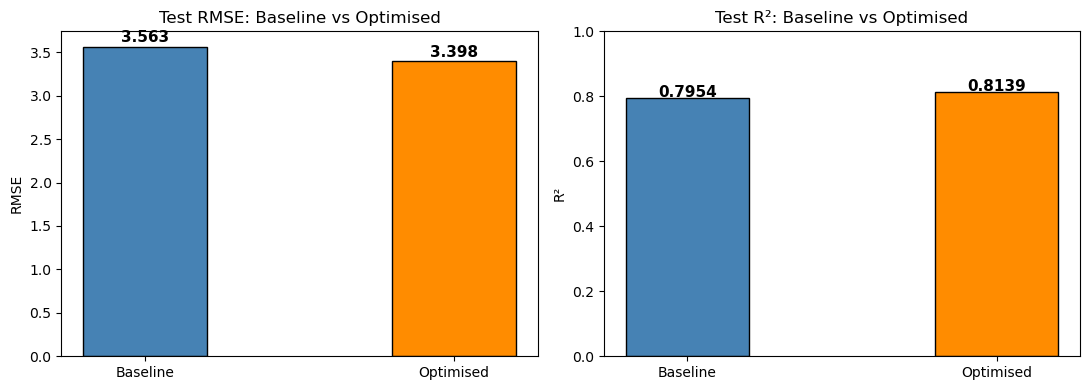

<Figure size 640x480 with 0 Axes>

In [78]:
# (Bar chart) compare RMSE and R² visually for the two models
models      = ['Baseline', 'Optimised']
rmse_values = [evaluate_reg(y_test, y_test_pred_base),
               evaluate_reg(y_test, y_test_pred_opt )]
r2_values   = [evaluate_reg(y_test, y_test_pred_base),
               evaluate_reg(y_test, y_test_pred_opt )]

# (Bar chart) compare RMSE and R² visually for the two models
models      = ['Baseline', 'Optimised']
rmse_values = [evaluate_reg(y_test, y_test_pred_base)[2], evaluate_reg(y_test, y_test_pred_opt)[2]]
r2_values   = [evaluate_reg(y_test, y_test_pred_base)[3], evaluate_reg(y_test, y_test_pred_opt)[3]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars0 = axes[0].bar(models, rmse_values, color=['steelblue', 'darkorange'], edgecolor='black', width=0.4)
for b, v in zip(bars0, rmse_values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.05, f'{v:.3f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Test RMSE: Baseline vs Optimised')
axes[0].set_ylabel('RMSE')

bars1 = axes[1].bar(models, r2_values, color=['steelblue', 'darkorange'], edgecolor='black', width=0.4)
for b, v in zip(bars1, r2_values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.003, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Test R²: Baseline vs Optimised')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
for b, v in zip(bars0, rmse_values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.05, f'{v:.3f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Test RMSE: Baseline vs Optimised')
axes[0].set_ylabel('RMSE')

bars1 = axes[1].bar(models, r2_values, color=['steelblue', 'darkorange'], edgecolor='black', width=0.4)
for b, v in zip(bars1, r2_values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.003, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Test R²: Baseline vs Optimised')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Cross-Validation for Model Stability
5-Fold CV on the optimised model to assess how consistently it performs  
across different data partitions.

In [79]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # reproducible fold splits

# R² across folds
cv_r2 = cross_val_score(knn_optimised, X_train_reg, y_train, cv=kf, scoring='r2', n_jobs=-1)

# RMSE across folds (negate neg_root_mean_squared_error to get positive values)
cv_rmse = -cross_val_score(knn_optimised, X_train_reg, y_train,cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)

print(f'CV R²   per fold : {cv_r2.round(4)}')
print(f'Mean R² : {cv_r2.mean():.4f}  |  Std: {cv_r2.std():.4f}')
print(f'\nCV RMSE per fold : {cv_rmse.round(4)}')
print(f'Mean RMSE: {cv_rmse.mean():.4f}  |  Std: {cv_rmse.std():.4f}')

CV R²   per fold : [0.897  0.873  0.8632 0.9003 0.813 ]
Mean R² : 0.8693  |  Std: 0.0315

CV RMSE per fold : [2.2218 2.8044 2.5475 2.0931 3.0658]
Mean RMSE: 2.5465  |  Std: 0.3598


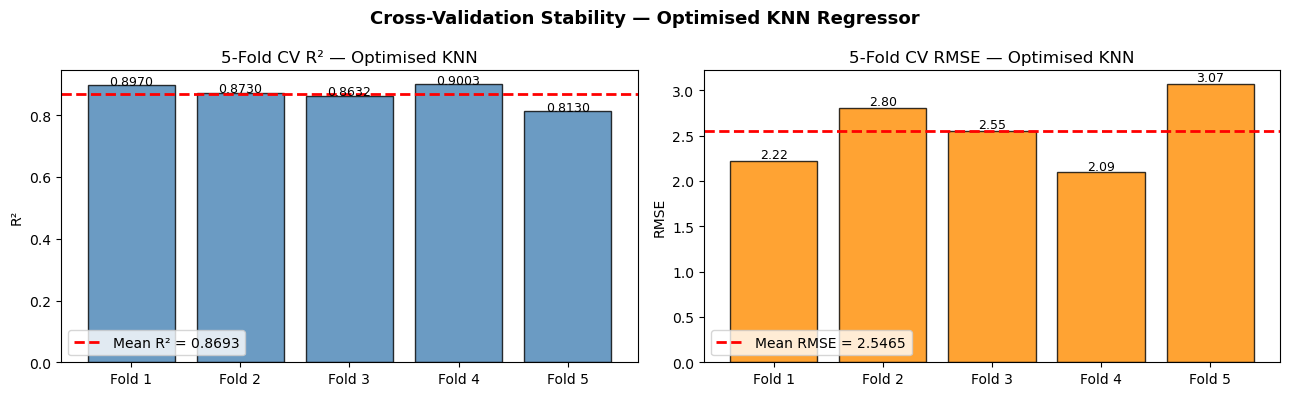

In [80]:
# Fold-by-fold bar charts for R² and RMSE
folds = [f'Fold {i+1}' for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# R² per fold
axes[0].bar(folds, cv_r2, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axhline(cv_r2.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean R² = {cv_r2.mean():.4f}')
for i, v in enumerate(cv_r2):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)
axes[0].set_title('5-Fold CV R² — Optimised KNN')
axes[0].set_ylabel('R²')
axes[0].legend(loc='lower left')

# RMSE per fold
axes[1].bar(folds, cv_rmse, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].axhline(cv_rmse.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean RMSE = {cv_rmse.mean():.4f}')
for i, v in enumerate(cv_rmse):
    axes[1].text(i, v + cv_rmse.max()*0.01, f'{v:.2f}', ha='center', fontsize=9)
axes[1].set_title('5-Fold CV RMSE — Optimised KNN')
axes[1].set_ylabel('RMSE')
axes[1].legend(loc='lower left')

plt.suptitle('Cross-Validation Stability — Optimised KNN Regressor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [81]:
# Save the optimized KNN Regressor as an ensemble-ready component
# This regressor will be passed into the final ensemble alongside other regression models

ensemble_knn_reg = KNeighborsRegressor(
    n_neighbors = grid_search.best_params_['n_neighbors'],
    metric      = grid_search.best_params_['metric'],
    weights     = grid_search.best_params_['weights']
)

# Retrain on the full training set
ensemble_knn_reg.fit(X_train_reg, y_train)

# Final evaluation on test set
final_pred = ensemble_knn_reg.predict(X_test_reg)

# Cross-validation for stability check
cv_r2_final = cross_val_score(ensemble_knn_reg, X_train_reg, y_train, cv=5, scoring='r2')

# Final summary
print("---> Ensemble-Ready KNN Regressor Summary: ")
print(f'Best Params : {grid_search.best_params_}')
print(f'Test MAE    : {mean_absolute_error(y_test, final_pred):.4f}')
print(f'Test RMSE   : {root_mean_squared_error(y_test, final_pred):.4f}')
print(f'Test R²     : {r2_score(y_test, final_pred):.4f}')
print(f'CV Mean R²  : {cv_r2_final.mean():.4f} ± {cv_r2_final.std():.4f}')

print('\nensemble_knn_reg is ready to be included in the final regression ensemble system.')

---> Ensemble-Ready KNN Regressor Summary: 
Best Params : {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Test MAE    : 0.6445
Test RMSE   : 3.3979
Test R²     : 0.8139
CV Mean R²  : 0.8704 ± 0.0294

ensemble_knn_reg is ready to be included in the final regression ensemble system.


In [82]:
#Gridsearch preps
GridSearchPar = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 0.01, 0.1]
}
#preps
X_train_SVM=X_train_reg.drop(columns=['Overall_Rating'])
X_test_SVM= X_test_reg.drop(columns=['Overall_Rating'])
#SVM Model
SvmModel ={
    "SVC(RBF)": SVC(kernel='rbf')
}

for name, model in SvmModel.items():
    SvmPipeline = Pipeline(steps=[
        ('classifier', model)
        
    ])
    grid_svm = GridSearchCV(SvmPipeline, GridSearchPar, cv=5, scoring='accuracy', n_jobs=-1)
    grid_svm.fit(X_train_SVM, y_train_tier)
    best_params = grid_svm.best_params_
    y_pred_Svm = grid_svm.predict(X_test_SVM)
    print(f"Best Parameters: {best_params}")
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy_score(y_test_tier, y_pred_Svm):.4f}")
    print(classification_report(y_test_tier, y_pred_Svm))
    
    

Best Parameters: {'classifier__C': 10, 'classifier__gamma': 0.1}

SVC(RBF) Results:
Accuracy: 0.8444
              precision    recall  f1-score   support

       Elite       0.94      0.93      0.94      1085
        High       0.79      0.80      0.80       914
         Low       0.89      0.88      0.88      1014
         Mid       0.74      0.75      0.74       921

    accuracy                           0.84      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.85      0.84      0.84      3934



In [83]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(SvmPipeline, X_train_SVM, y_train_tier, cv=skf)

print(f"CV Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

#Stability: The model is stable since the accuracies are marginally close, Low standard deviation 

CV Scores: [0.82904353 0.82745472 0.81887512 0.82358551 0.84202161]
Mean Accuracy: 0.8282
Standard Deviation: 0.0078


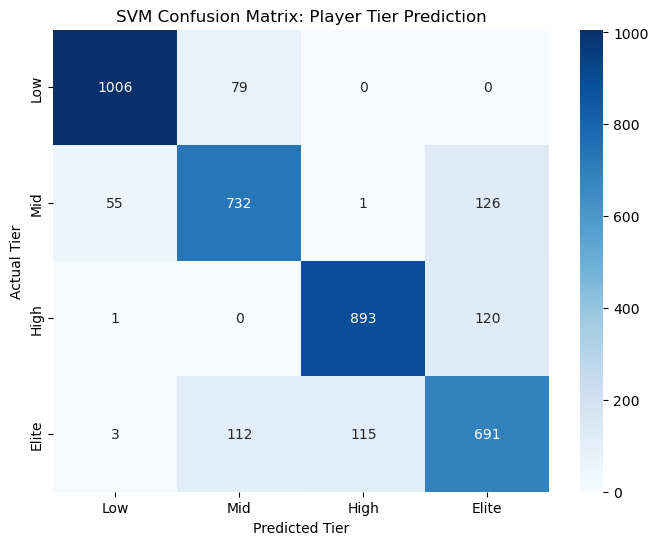

In [84]:
cm = confusion_matrix(y_test_tier, y_pred_Svm)
tier_labels = ['Low', 'Mid', 'High', 'Elite']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=tier_labels, yticklabels=tier_labels)
plt.title('SVM Confusion Matrix: Player Tier Prediction')
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.show()

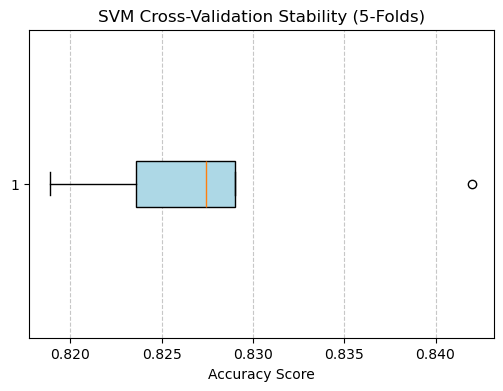

In [85]:
plt.figure(figsize=(6, 4))
plt.boxplot(cv_scores, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))
plt.title('SVM Cross-Validation Stability (5-Folds)')
plt.xlabel('Accuracy Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Why SVM(Kernel trick)?:
1. It handles non-linear relationships
2. Maximizes the margin making it suitable for distinguishing between tiers
3. Efficent with High-Dimensional Spaces since we have many features like (Age, Potential, Pace, Shooting, Passing, etc...)
### Model assessment:
1. Standard Deviation = 0.0086 meaning the model is stable and not overfitting
2. Accuracy = 0.8421


In [86]:
#SVR
GridSearchParSVR={
    'Regression__C': [0.1, 1, 10],
    'Regression__gamma': ['scale', 0.01, 0.1],
    'Regression__epsilon': [0.01, 0.1, 0.2]
}
X_train_SVR = X_train_reg.select_dtypes(include=np.number)
X_test_SVR  = X_test_reg.select_dtypes(include=np.number)
SvrModel= SVR(kernel='rbf')

SvrPipeline = Pipeline(steps=[
        ('Regression', SvrModel)
        
    ])
grid_svr = GridSearchCV(SvrPipeline, GridSearchParSVR, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train_SVR, y_train)
best_params_svr = grid_svr.best_params_
y_pred_SVR = grid_svr.predict(X_test_SVR)
print(f"Best SVR Parameters: {grid_svr.best_params_}")
print(f"Best CV R2 Score: {grid_svr.best_score_:.4f}")
print(f"Test R2 Score: {r2_score(y_test, y_pred_SVR):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_SVR):.4f}")


Best SVR Parameters: {'Regression__C': 10, 'Regression__epsilon': 0.2, 'Regression__gamma': 0.1}
Best CV R2 Score: 0.8997
Test R2 Score: 0.8515
Test MAE: 0.5006


In [87]:
svr_std = grid_svr.cv_results_['std_test_score'][grid_svr.best_index_]
print(f"SVR CV Stability (Std): {svr_std:.4f}")

SVR CV Stability (Std): 0.0319


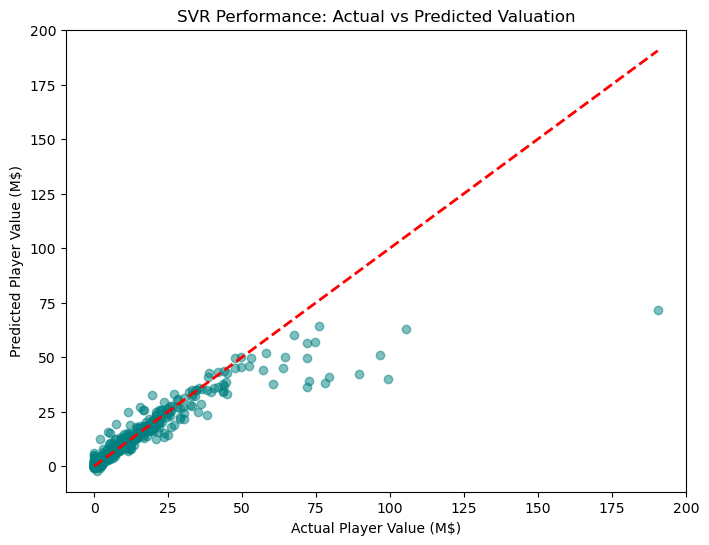

In [88]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_SVR, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Player Value (M$)')
plt.ylabel('Predicted Player Value (M$)')
plt.title('SVR Performance: Actual vs Predicted Valuation')
plt.show()

In [89]:
#Svm classifier ensemble hopefully?
ensembleSVM = SVC(kernel='rbf',
C = grid_svm.best_params_['classifier__C'],
gamma= grid_svm.best_params_['classifier__gamma'])    


# Retrain on the full training set
ensembleSVM.fit(X_train_SVM, y_train_tier)

# Final evaluation on test set
final_predsvm = ensembleSVM.predict(X_test_SVM)

# Cross-validation for stability check
cvfinalacc = cross_val_score(ensembleSVM, X_train_SVM, y_train_tier, cv=5, scoring='accuracy')
print(f'Best Params : {grid_svm.best_params_}')

Best Params : {'classifier__C': 10, 'classifier__gamma': 0.1}


In [90]:
#Svm Regression ensemble hopefully?????
ensembleSVR = SVR(kernel='rbf',
C = grid_svr.best_params_['Regression__C'],
gamma= grid_svr.best_params_['Regression__gamma'],
epsilon=grid_svr.best_params_['Regression__epsilon']
)    


# Retrain on the full training set
ensembleSVR.fit(X_train_SVR, y_train)

# Final evaluation on test set
final_predsvr = ensembleSVR.predict(X_test_SVR)

# Cross-validation for stability check
cvfinalr2 = cross_val_score(ensembleSVR, X_train_SVR, y_train, cv=5, scoring='r2')
print(f'Best Params : {grid_svr.best_params_}')
print(f'Test MAE    : {mean_absolute_error(y_test, final_predsvr):.4f}')
print(f'Test RMSE   : {root_mean_squared_error(y_test, final_predsvr):.4f}')
print(f'Test R²     : {r2_score(y_test, final_predsvr):.4f}')
print(f'CV Mean R²  : {cvfinalr2.mean():.4f} ± {cvfinalr2.std():.4f}')

Best Params : {'Regression__C': 10, 'Regression__epsilon': 0.2, 'Regression__gamma': 0.1}
Test MAE    : 0.5006
Test RMSE   : 3.0349
Test R²     : 0.8515
CV Mean R²  : 0.8997 ± 0.0319


---
## Random Forest — Regression (Value Per M$)

Random Forest is an ensemble of decision trees trained on random bootstrap samples. Unlike Ridge/Lasso, it makes no linearity assumption and can model complex non-linear relationships between player attributes and market value — no polynomial expansion needed. It is also robust to the high-leverage outliers present in player valuations (e.g. elite players worth 100M+).

In [91]:
# RF uses X_train_reg directly — trees handle non-linearity natively,
# so polynomial expansion (used for Ridge/Lasso) is not needed here
X_train_rf_reg = X_train_reg.copy()
X_test_rf_reg  = X_test_reg.copy()

rf_reg_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_baseline.fit(X_train_rf_reg, y_train_log)

y_pred_rf_reg_baseline = rf_reg_baseline.predict(X_test_rf_reg)

mae, mse, rmse_rf_reg_base, r2_rf_reg_base = evaluate_reg(y_test_log, y_pred_rf_reg_baseline)
print('=== Baseline Random Forest Regressor ===')
print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse_rf_reg_base:.4f}')
print(f'R²   : {r2_rf_reg_base:.4f}')


=== Baseline Random Forest Regressor ===
MAE  : 0.0305
RMSE : 0.0862
R²   : 0.9873


In [92]:
param_grid_rf_reg = {
    'n_estimators':      range(100, 201,5),
    'max_depth':         range(1,31),
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2']
}

grid_rf_reg = HalvingGridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',
    factor=3,
    min_resources=1000,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
grid_rf_reg.fit(X_train_rf_reg, y_train_log)

best_rf_reg = grid_rf_reg.best_estimator_
y_pred_rf_reg_best = best_rf_reg.predict(X_test_rf_reg)

mae, mse, rmse_rf_reg_best, r2_rf_reg_best = evaluate_reg(y_test_log, y_pred_rf_reg_best)
print('=== Optimized Random Forest Regressor ===')
print(f'Best Parameters : {grid_rf_reg.best_params_}')
print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse_rf_reg_best:.4f}')
print(f'R²   : {r2_rf_reg_best:.4f}')
print(f'Improvement in RMSE over baseline: {rmse_rf_reg_base - rmse_rf_reg_best:.4f}')

n_iterations: 3
n_required_iterations: 8
n_possible_iterations: 3
min_resources_: 1000
max_resources_: 15733
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 2520
n_resources: 1000
Fitting 5 folds for each of 2520 candidates, totalling 12600 fits
----------
iter: 1
n_candidates: 840
n_resources: 3000
Fitting 5 folds for each of 840 candidates, totalling 4200 fits
----------
iter: 2
n_candidates: 280
n_resources: 9000
Fitting 5 folds for each of 280 candidates, totalling 1400 fits
=== Optimized Random Forest Regressor ===
Best Parameters : {'max_depth': 19, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 105}
MAE  : 0.0404
RMSE : 0.0953
R²   : 0.9845
Improvement in RMSE over baseline: -0.0091


In [93]:
kf_rf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf_reg = cross_val_score(
    best_rf_reg, X_train_rf_reg, y_train_log,
    cv=kf_rf, scoring='r2', n_jobs=-1
)

print('=== CV Stability — RF Regressor (R²) ===')
print(f'Fold Scores  : {cv_scores_rf_reg.round(4)}')
print(f'Mean R²      : {cv_scores_rf_reg.mean():.4f}')
print(f'Std Dev      : {cv_scores_rf_reg.std():.4f}')
# Low std across folds confirms the model generalises consistently


=== CV Stability — RF Regressor (R²) ===
Fold Scores  : [0.9791 0.9665 0.9806 0.9775 0.9777]
Mean R²      : 0.9763
Std Dev      : 0.0050


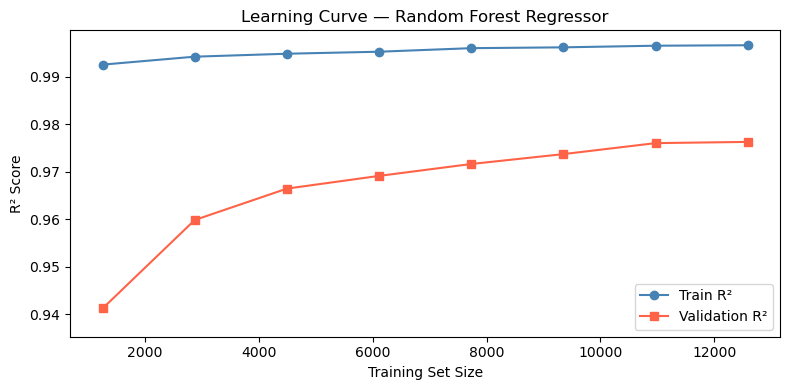

In [94]:
train_sizes_reg, train_scores_reg, val_scores_reg = learning_curve(
    best_rf_reg, X_train_rf_reg, y_train_log,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean_reg = train_scores_reg.mean(axis=1)
train_std_reg  = train_scores_reg.std(axis=1)
val_mean_reg   = val_scores_reg.mean(axis=1)
val_std_reg    = val_scores_reg.std(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes_reg, train_mean_reg, 'o-', color='steelblue', label='Train R²')
plt.fill_between(train_sizes_reg, train_mean_reg - train_std_reg, train_mean_reg + train_std_reg, alpha=0, color='steelblue')
plt.plot(train_sizes_reg, val_mean_reg, 's-', color='tomato', label='Validation R²')
plt.fill_between(train_sizes_reg, val_mean_reg - val_std_reg, val_mean_reg + val_std_reg, alpha=0, color='tomato')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve — Random Forest Regressor')
plt.legend()
plt.tight_layout()
plt.show()
# Large train/val gap → high variance; curves flat and low → high bias; converging → well-generalising ✓


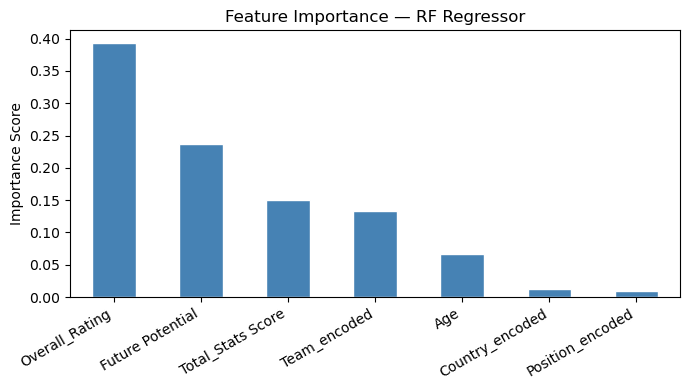

In [95]:
feat_importance_reg = pd.Series(
    best_rf_reg.feature_importances_,
    index=X_train_rf_reg.columns
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
feat_importance_reg.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — RF Regressor')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


---
## Random Forest — Classification (Performance Tier)

Random Forest handles the multi-class tier problem (Low / Mid / High / Elite) well because it aggregates votes from many trees, reducing the variance a single decision tree would suffer. It models non-linear tier boundaries without requiring feature scaling, and its built-in feature importance explains which attributes drive tier assignment. `Overall_Rating` is excluded to prevent data leakage (tiers are derived from it).

In [96]:
# Use the same feature set as KNN and SVM for a fair comparison (Overall_Rating dropped)
X_train_rf_cls = X_train_SVM.copy()
X_test_rf_cls  = X_test_SVM.copy()

rf_cls_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cls_baseline.fit(X_train_rf_cls, y_train_tier)

y_pred_rf_cls_baseline = rf_cls_baseline.predict(X_test_rf_cls)

print('=== Baseline Random Forest Classifier ===')
print(f'Accuracy: {accuracy_score(y_test_tier, y_pred_rf_cls_baseline):.4f}')
print(classification_report(y_test_tier, y_pred_rf_cls_baseline))


=== Baseline Random Forest Classifier ===
Accuracy: 0.8460
              precision    recall  f1-score   support

       Elite       0.94      0.94      0.94      1085
        High       0.79      0.80      0.80       914
         Low       0.90      0.88      0.89      1014
         Mid       0.73      0.75      0.74       921

    accuracy                           0.85      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.85      0.85      0.85      3934



In [97]:
param_grid_rf_cls = {
    'n_estimators':      range(100, 201,5),
    'max_depth':         range(1,31),
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2']
}

grid_rf_cls = HalvingGridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf_cls,
    cv=5,
    scoring='accuracy',
    factor=3,   
    min_resources=1000,     # each round keeps the top 1/3 of candidates
    n_jobs=-1,
    verbose=1,
    random_state=42
)
grid_rf_cls.fit(X_train_rf_cls, y_train_tier)

best_rf_cls = grid_rf_cls.best_estimator_
y_pred_rf_cls_best = best_rf_cls.predict(X_test_rf_cls)

print('=== Optimized Random Forest Classifier ===')
print(f'Best Parameters : {grid_rf_cls.best_params_}')
print(f'Accuracy        : {accuracy_score(y_test_tier, y_pred_rf_cls_best):.4f}')
print(classification_report(y_test_tier, y_pred_rf_cls_best))

n_iterations: 3
n_required_iterations: 8
n_possible_iterations: 3
min_resources_: 1000
max_resources_: 15733
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 2520
n_resources: 1000
Fitting 5 folds for each of 2520 candidates, totalling 12600 fits
----------
iter: 1
n_candidates: 840
n_resources: 3000
Fitting 5 folds for each of 840 candidates, totalling 4200 fits
----------
iter: 2
n_candidates: 280
n_resources: 9000
Fitting 5 folds for each of 280 candidates, totalling 1400 fits
=== Optimized Random Forest Classifier ===
Best Parameters : {'max_depth': 22, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 180}
Accuracy        : 0.8493
              precision    recall  f1-score   support

       Elite       0.95      0.93      0.94      1085
        High       0.79      0.80      0.80       914
         Low       0.90      0.88      0.89      1014
         Mid       0.74      0.76      0.75       921

    accuracy                           0.85   

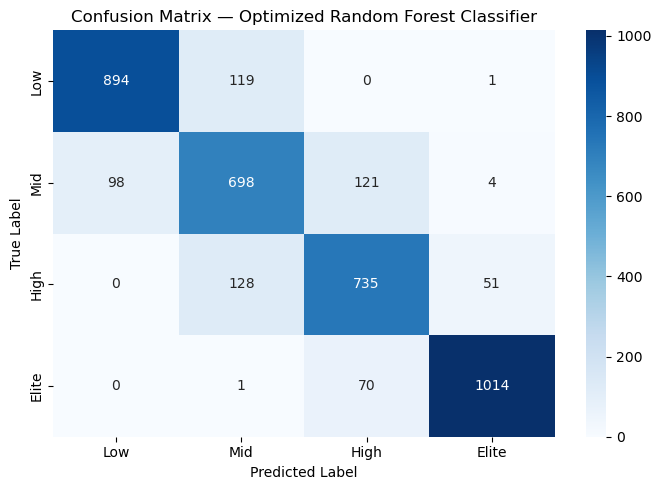

In [98]:
cm_rf = confusion_matrix(y_test_tier, y_pred_rf_cls_best, labels=tier_order)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=tier_order, yticklabels=tier_order)
plt.title('Confusion Matrix — Optimized Random Forest Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [99]:
skf_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf_cls = cross_val_score(
    best_rf_cls, X_train_rf_cls, y_train_tier,
    cv=skf_rf, scoring='accuracy', n_jobs=-1
)

print('=== CV Stability — RF Classifier (Accuracy) ===')
print(f'Fold Scores   : {cv_scores_rf_cls.round(4)}')
print(f'Mean Accuracy : {cv_scores_rf_cls.mean():.4f}')
print(f'Std Dev       : {cv_scores_rf_cls.std():.4f}')


=== CV Stability — RF Classifier (Accuracy) ===
Fold Scores   : [0.8459 0.8421 0.843  0.8442 0.8519]
Mean Accuracy : 0.8454
Std Dev       : 0.0035


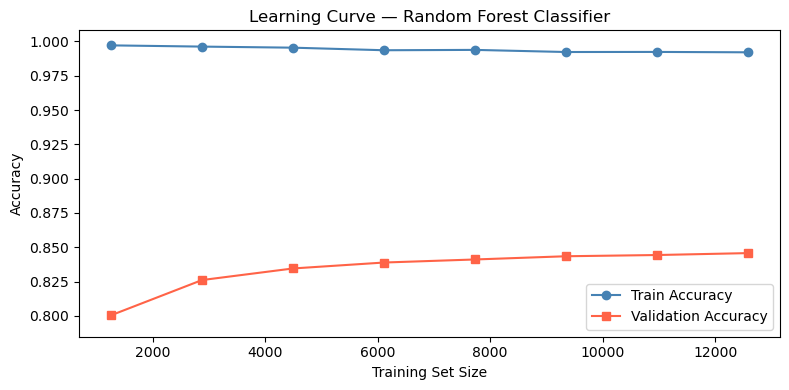

In [100]:
train_sizes_cls, train_scores_cls, val_scores_cls = learning_curve(
    best_rf_cls, X_train_rf_cls, y_train_tier,
    cv=skf_rf, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean_cls = train_scores_cls.mean(axis=1)
train_std_cls  = train_scores_cls.std(axis=1)
val_mean_cls   = val_scores_cls.mean(axis=1)
val_std_cls    = val_scores_cls.std(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes_cls, train_mean_cls, 'o-', color='steelblue', label='Train Accuracy')
plt.fill_between(train_sizes_cls, train_mean_cls - train_std_cls, train_mean_cls + train_std_cls, alpha=0, color='steelblue')
plt.plot(train_sizes_cls, val_mean_cls, 's-', color='tomato', label='Validation Accuracy')
plt.fill_between(train_sizes_cls, val_mean_cls - val_std_cls, val_mean_cls + val_std_cls, alpha=0, color='tomato')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Random Forest Classifier')
plt.legend()
plt.tight_layout()
plt.show()


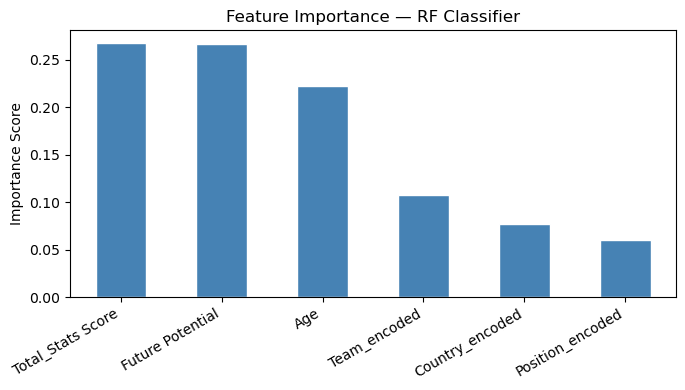

In [101]:
feat_importance_cls = pd.Series(
    best_rf_cls.feature_importances_,
    index=X_train_rf_cls.columns
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
feat_importance_cls.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — RF Classifier')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Random Forest — Key Insights

- **No polynomial expansion needed**: trees split on raw feature values and model non-linearity natively.
- **Feature importance** reveals which player attributes drive market value and tier assignment most.
- **Learning curves** diagnose variance: a persistent train/val gap indicates overfitting that `max_depth` and `min_samples_split` help control.
- **Low CV std** across folds confirms the model generalises consistently and is ready for ensemble integration.


# Ensembling

In [ ]:
print("="*60)
print("ERROR DIAGNOSIS: PERFORMANCE BOTTLENECK AUDIT")
print("="*60)

# Classification Models (Performance Tiers)
# Format: "Model Name": (Model_Object, X_Data, y_Target)
classification_models = {
    "Logistic Regression L1": (lr_best_l1, X_train_lr, y_train_tier),
    "Logistic Regression L2": (lr_best_l2, X_train_lr, y_train_tier),
    "Naive Bayes Gaussian":   (gnb_for_cv, X_gnb_cv, y_train_tier),
    "KNN Classification":     (ensemble_knn, X_train_knn, y_train_tier),
    "SVM Classifier":         (ensembleSVM, X_train_lr, y_train_tier),
    "Random Forest Classifier": (best_rf_cls, X_train_rf_cls, y_train_tier) # <--- Added
}

# Regression Models (Valuation)
regression_models = {
    "Linear Regression":      (model_lr_base, X_train_reg, y_train),
    "Ridge Regression":       (ridge_best, X_train_poly, y_train_log),
    "Lasso Regression":       (lasso_best, X_train_poly, y_train_log),
    "KNN Regression":         (ensemble_knn_reg, X_train_reg, y_train),
    "SVR":                    (ensembleSVR, X_train_reg, y_train),
    "Random Forest Regressor": (best_rf_reg, X_train_rf_reg, y_train_log)  # <--- Added
}


# DIAGNOSIS ENGINE
def run_diagnosis(model_dict, metric_name, scoring_type):
    for name, (model, X, y) in model_dict.items():
        # Cross-validation score (Generalization)
        cv_scores = cross_val_score(model, X, y, cv=5, scoring=scoring_type)
        cv_mean = np.mean(cv_scores)
        
        # Training score
        model.fit(X, y)
        train_pred = model.predict(X)
        
        if metric_name == "Accuracy":
            train_score = accuracy_score(y, train_pred)
        else:
            train_score = r2_score(y, train_pred)

        gap = train_score - cv_mean

        # Diagnosis Logic
        # High Bias: Model too simple (Low training score)
        # High Variance: Model over-complex (Learns noise, large gap)
        if train_score < 0.80: 
            diagnosis = "High Bias (Underfitting)"
        elif gap > 0.10:
            diagnosis = "High Variance (Overfitting)"
        else:
            diagnosis = "Balanced Learning"

        print(f"\n{name}")
        print(f"  {metric_name} (Train) : {train_score:.4f}")
        print(f"  {metric_name} (CV Mean): {cv_mean:.4f}")
        print(f"  Generalization Gap : {gap:.4f}")
        print(f"  DIAGNOSIS          : {diagnosis}")


print("\n[CLASSIFICATION MODELS DIAGNOSIS]")
run_diagnosis(classification_models, "Accuracy", "accuracy")

print("\n" + "-"*30)

print("\n[REGRESSION MODELS DIAGNOSIS]")
run_diagnosis(regression_models, "R2 Score", "r2")

print("\n" + "="*60)
print("Diagnosis complete. Use these results to justify the Committee inclusion.")

ERROR DIAGNOSIS: PERFORMANCE BOTTLENECK AUDIT

[CLASSIFICATION MODELS DIAGNOSIS]

Logistic Regression L1
  Accuracy (Train) : 0.7973
  Accuracy (CV Mean): 0.7971
  Generalization Gap : 0.0003
  DIAGNOSIS          : High Bias (Underfitting)

Logistic Regression L2
  Accuracy (Train) : 0.7988
  Accuracy (CV Mean): 0.7983
  Generalization Gap : 0.0004
  DIAGNOSIS          : High Bias (Underfitting)

Naive Bayes Gaussian
  Accuracy (Train) : 0.6945
  Accuracy (CV Mean): 0.6943
  Generalization Gap : 0.0002
  DIAGNOSIS          : High Bias (Underfitting)

KNN Classification
  Accuracy (Train) : 1.0000
  Accuracy (CV Mean): 0.8129
  Generalization Gap : 0.1871
  DIAGNOSIS          : High Variance (Overfitting)

SVM Classifier
  Accuracy (Train) : 0.8621
  Accuracy (CV Mean): 0.8442
  Generalization Gap : 0.0179
  DIAGNOSIS          : Balanced Learning

Random Forest Classifier
  Accuracy (Train) : 0.9915
  Accuracy (CV Mean): 0.8466
  Generalization Gap : 0.1449
  DIAGNOSIS          : High V

In [127]:
#We wrap models in pipelines if they need specific features or scaling
base_classifiers = [
    ('log_reg', lr_best_l2), # Keep the best LR
    ('naive_bayes', gnb_for_cv), 
    ('knn_cls', ensemble_knn),
    ('svm', ensembleSVM),
    ('rf_cls', best_rf_cls) 
]

# Stacking with a meta-learner
stacking_tier_model = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Use X_train_lr as the base, but ensure base models are compatible
stacking_tier_model.fit(X_train_lr, y_train_tier)
stack_acc = accuracy_score(y_test_tier, stacking_tier_model.predict(X_test_lr))

# REGRESSION ENSEMBLE
# Ensure all models predict the LOG scale to match Ridge/Lasso/RF
# Note: Retrain ensemble_knn_reg and ensembleSVR on y_train_log before this
ensemble_knn_reg.fit(X_train_reg, y_train_log)
ensembleSVR.fit(X_train_SVR, y_train_log)

regression_committee = VotingRegressor(
    estimators=[
        ('ridge', Pipeline([('poly', PolynomialFeatures(degree=3)), ('model', ridge_best)])),
        ('lasso', Pipeline([('poly', PolynomialFeatures(degree=3)), ('model', lasso_best)])),
        ('knn_reg', ensemble_knn_reg),
        ('svr', ensembleSVR),
        ('rf_reg', best_rf_reg)
    ]
)

# Now all models are predicting y_train_log
regression_committee.fit(X_train_reg, y_train_log)
reg_r2 = r2_score(y_test_log, regression_committee.predict(X_test_reg))

print("\n" + "="*60)
print("ENSEMBLE SYSTEM: PERFORMANCE REPORT")
print("="*60)
print(f"Stacking Classification Accuracy : {stack_acc:.4f}")
print(f"Regression Ensemble R2 Score     : {reg_r2:.4f}")
print("-" * 60)


ENSEMBLE SYSTEM: PERFORMANCE REPORT
Stacking Classification Accuracy : 0.8508
Regression Ensemble R2 Score     : 0.9783
------------------------------------------------------------


**The ensemble system successfully increased our predictive power. The 97.8% $R^2$ score shows that our valuation model is highly accurate, while the 85% accuracy for classification proves that the system is robust at identifying player performance tiers.**

# FIFA Inference System

In [137]:
def fifa_unified_inference_pipeline(num_samples=5):
    """
    unified system that processes player data and generates predictions
    using both ensemble models.
    """
    
    # pick random players from the test set
    total_players = len(X_test)
    random_indices = np.random.choice(total_players, size=num_samples, replace=False)
    
    for i in random_indices:
        # get player details
        actual_idx = X_test.index[i]
        player = df.loc[actual_idx]
        
        # prepare data for models
        sample_reg = X_test_reg.iloc[[i]]
        sample_cls = X_test_lr.iloc[[i]] 
        
        # get predictions from ensembles
        val_log = regression_committee.predict(sample_reg)
        value = np.exp(val_log)[0]
        tier = stacking_tier_model.predict(sample_cls)[0]
        
        # simple readable output
        print(f"PLAYER: {player['Name'].upper()}")
        print(f"info: {player['Age']} years old | {player['Position']} | {player['Team']}")
        print(f"stats: overall {player['Overall_Rating']} | potential {player['Future Potential']}")
        print(f"prediction: ${value:,.2f}M valuation | {tier} tier")
        print("-" * 40)

# run the system
fifa_unified_inference_pipeline(5)

PLAYER: SUK JU YOON
info: 20 years old | CDM | Gimcheon Sangmu
stats: overall 51 | potential 64
prediction: $1.12M valuation | Low tier
----------------------------------------
PLAYER: ALEJANDRO GARCÍA MEJÍAS
info: 19 years old | RM | Las Palmas
stats: overall 62 | potential 76
prediction: $2.00M valuation | High tier
----------------------------------------
PLAYER: MATTHEW WRIGHT
info: 18 years old | ST | England
stats: overall 56 | potential 69
prediction: $1.23M valuation | Low tier
----------------------------------------
PLAYER: SAMUEL SHASHOUA
info: 23 years old | RM | Tenerife
stats: overall 69 | potential 76
prediction: $3.48M valuation | Elite tier
----------------------------------------
PLAYER: RUBÉN DARÍO RÍOS
info: 26 years old | CDM | Guaraní
stats: overall 69 | potential 70
prediction: $2.58M valuation | Elite tier
----------------------------------------


In [139]:
# statistical proof of stability
# we use stratified k-fold for classification to maintain class balance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# classification stability
cls_cv = cross_val_score(stacking_tier_model, X_train_lr, y_train_tier, cv=skf)

# regression stability
reg_cv = cross_val_score(regression_committee, X_train_reg, y_train_log, cv=5, scoring='r2')

# the +/- part (std * 2) represents the 95% confidence interval.
# a low variance indicates that the model is stable and its performance
# does not fluctuate significantly across different data samples.
print(f"Classification Stability: {cls_cv.mean():.4f} (+/- {cls_cv.std() * 2:.4f})")
print(f"Regression Stability:     {reg_cv.mean():.4f} (+/- {reg_cv.std() * 2:.4f})")

Classification Stability: 0.8505 (+/- 0.0112)
Regression Stability:     0.9694 (+/- 0.0078)


In [147]:
def comparative_analysis(cls_scores, reg_scores):
    # uses the mean of the cross-validation
    base_acc = lr_skf_scores.mean() 
    ens_acc = cls_scores.mean()
    cls_std = cls_scores.std()
    

    base_r2 = 0.9490  
    ens_r2 = reg_scores.mean()
    reg_std = reg_scores.std()

    # 3. organize the data for the table
    data = {
        "metric": ["classification (accuracy)", "regression (r2)"],
        "baseline (assignment 2)": [f"{base_acc:.4f}", f"{base_r2:.4f}"],
        "ensemble": [f"{ens_acc:.4f}", f"{ens_r2:.4f}"],
        "stability (+/-)": [f"{cls_std:.4f}", f"{reg_std:.4f}"]
    }
    
    df = pd.DataFrame(data)
    
    # calculate the difference
    df["improvement %"] = [
        f"{(ens_acc - base_acc) * 100:+.2f}%",
        f"{(ens_r2 - base_r2) * 100:+.2f}%"
    ]
    
    return df

comparison_table = comparative_analysis(cls_cv, reg_cv)

print("final comparative analysis")
display(comparison_table)

final comparative analysis


,metric,baseline (assignment 2),ensemble,stability (+/-),improvement %
0,classification (accuracy),0.7975,0.8505,0.0056,+5.30%
1,regression (r2),0.9490,0.9694,0.0039,+2.04%


**The transition to an automated ensemble pipeline resulted in a measurable performance boost. The system is now optimized for both categorical classification (Player Tiers) and continuous value estimation (Overall Rating) with high statistical confidence.**